在我们的预测中,比如说有一些因素会随着时间而逐步改变,而我们并不知道.假设这些因素会随着时间变化,而我们的数据集中并没有包含时间这一维度,如果我们按照天来计算,以第一个数据为数字1,增加天数这一维度,是否能将一些未知因素纳入其中?

加入了一个时间趋势,我们把一些随着时间改进的因素考虑在内,但我们并不知道是什么,具体是什么关系.比如,我们考虑到紫金矿业是一个扩张性企业,它的矿产量可能一直在增长.处于趋势之中,加入一个变量应该可以延续.但是对于反转的趋势,可能之前学到的经验就有错误了.

# 对照实验：加入实际日历天数

基准模型为 **7→16→32→1**；实验模型为 **8→16→32→1**，只新增一个 `elapsed_days` 因子：**(当前日期 − 整个数据集首日).days + 1**。首日为1，周末、节假日也计入经过的天数，不补造缺失日期的训练记录。

使用全部历史数据。**2026-01-01之前为完整训练集，2026-01-01及以后为测试集**，完整训练集末尾5%作为内部验证集。两组使用完全相同日期及目标。

保持 ReLU、Adam、LR=0.01、seed=42、2000轮上限、MIN_DELTA=1e-6、连续100轮验证误差未改善早停。各自选择最佳轮数后，重新初始化，在各自完整训练集重训。标准化只在相应拟合段学习参数，包括时间因子；时间计数原点始终固定为原数据首日。

时间趋势可能代理随时间变化的遗漏因素，但不能据此认定学到了产量等具体因果关系，也不保证未来趋势延续。本次不加入Lasso。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
OUT = ROOT / 'results/mlp_time_dimension_05'
OUT.mkdir(parents=True, exist_ok=True)
SEED, LR, MAX_EPOCHS, PATIENCE, MIN_DELTA = 42, 0.01, 2000, 100, 1e-6
TEST_START, VAL_FRACTION = pd.Timestamp('2026-01-01'), 0.05
torch.set_num_threads(1)
dataset_path = ROOT / 'src/pickle/Dataset.pkl'
dataset = pd.read_pickle(dataset_path)
X_base, Y = dataset['X'].copy(), dataset['Y'].copy()
assert X_base.index.equals(Y.index) and X_base.shape[1] == 7
assert isinstance(X_base.index, pd.DatetimeIndex)
assert X_base.index.is_unique and X_base.index.is_monotonic_increasing
assert np.isfinite(X_base.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
origin = X_base.index.min().normalize()
X_time = X_base.copy()
X_time['elapsed_days'] = (X_time.index.normalize() - origin).days + 1
assert X_time.elapsed_days.iloc[0] == 1
assert np.array_equal(np.diff(X_time.elapsed_days), np.diff(X_time.index.normalize().values).astype('timedelta64[D]').astype(int))
train_index = X_base.index[X_base.index < TEST_START]
test_index = X_base.index[X_base.index >= TEST_START]
cut = int(len(train_index) * (1 - VAL_FRACTION))
fit_index, val_index = train_index[:cut], train_index[cut:]
assert fit_index.max() < val_index.min() <= val_index.max() < test_index.min()
split_info = pd.DataFrame([{'数据段': name, '记录数': len(idx), '开始': idx.min(), '结束': idx.max()}
    for name, idx in [('内部拟合集', fit_index), ('内部验证集', val_index),
                      ('完整训练集', train_index), ('测试集', test_index)]])
display(split_info)
print('时间计数原点：', origin.date())
display(X_time[['elapsed_days']].head(10))
# 原数据首日是周三：周五为3，下一周一为6，相隔3个实际日历日。
assert X_time.loc['2012-05-14', 'elapsed_days'] - X_time.loc['2012-05-11', 'elapsed_days'] == 3


时间计数原点： 2012-05-09


,数据段,记录数,开始,结束
0,内部拟合集,3500,2012-05-09,2025-04-23
1,内部验证集,185,2025-04-24,2025-12-31
2,完整训练集,3685,2012-05-09,2025-12-31
3,测试集,152,2026-01-01,2026-07-23


,elapsed_days
2012-05-09,1
2012-05-10,2
2012-05-11,3
2012-05-14,6
2012-05-15,7
2012-05-16,8
2012-05-17,9
2012-05-18,10
2012-05-21,13
2012-05-22,14


## 1. 两组使用相同训练流程

各自独立标准化、选轮并重训；验证与测试目标不会用于拟合标准化器。保存内部最佳权重和最终权重，两者配套的标准化器不同。

In [ ]:
def tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32)

def build_model(n_inputs):
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(n_inputs, 16), nn.ReLU(),
                         nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 1))

def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}

def train_variant(features, key):
    sx = StandardScaler().fit(features.loc[fit_index])
    sy = StandardScaler().fit(Y.loc[fit_index].to_numpy().reshape(-1, 1))
    xf, xv = tensor(sx.transform(features.loc[fit_index])), tensor(sx.transform(features.loc[val_index]))
    yf = tensor(sy.transform(Y.loc[fit_index].to_numpy().reshape(-1, 1)))
    yv = tensor(sy.transform(Y.loc[val_index].to_numpy().reshape(-1, 1)))
    candidate = build_model(features.shape[1])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(candidate.parameters(), lr=LR)
    best_loss, best_epoch, waiting, best_state = float('inf'), 0, 0, None
    rows = []
    for epoch in range(1, MAX_EPOCHS + 1):
        candidate.train()
        loss = loss_fn(candidate(xf), yf)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        candidate.eval()
        with torch.no_grad():
            fit_mse = loss_fn(candidate(xf), yf).item()
            val_mse = loss_fn(candidate(xv), yv).item()
        assert np.isfinite(fit_mse) and np.isfinite(val_mse)
        rows.append([epoch, fit_mse, val_mse])
        if val_mse < best_loss - MIN_DELTA:
            best_loss, best_epoch, waiting = val_mse, epoch, 0
            best_state = deepcopy(candidate.state_dict())
        else:
            waiting += 1
        if waiting >= PATIENCE:
            break
    stopped_epoch = epoch
    candidate.load_state_dict(best_state)
    candidate.eval()
    with torch.no_grad():
        assert np.isclose(loss_fn(candidate(xv), yv).item(), best_loss)
        val_pred = sy.inverse_transform(candidate(xv).numpy()).ravel()
    sx_final = StandardScaler().fit(features.loc[train_index])
    sy_final = StandardScaler().fit(Y.loc[train_index].to_numpy().reshape(-1, 1))
    xt = tensor(sx_final.transform(features.loc[train_index]))
    yt = tensor(sy_final.transform(Y.loc[train_index].to_numpy().reshape(-1, 1)))
    model = build_model(features.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    final_curve = []
    for epoch in range(1, best_epoch + 1):
        model.train()
        loss = loss_fn(model(xt), yt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            final_curve.append(loss_fn(model(xt), yt).item())
    assert np.isfinite(final_curve).all()
    preds = {}
    for split, idx in [('Train', train_index), ('Test', test_index)]:
        with torch.no_grad():
            pred = sy_final.inverse_transform(model(tensor(sx_final.transform(features.loc[idx]))).numpy()).ravel()
        preds[split] = pd.Series(pred, index=idx)
    history = pd.DataFrame(rows, columns=['epoch', 'fit_mse', 'val_mse'])
    history.to_csv(OUT / f'{key}_selection_history.csv', index=False)
    torch.save({'model_state_dict': model.state_dict(), 'internal_best_state_dict': best_state,
        'n_inputs': features.shape[1], 'hidden_layers': [16, 32], 'feature_names': list(features.columns),
        'origin': str(origin.date()), 'time_formula': '(date - origin).days + 1',
        'scaler_x_internal': scaler_state(sx), 'scaler_y_internal': scaler_state(sy),
        'scaler_x_final': scaler_state(sx_final), 'scaler_y_final': scaler_state(sy_final),
        'best_epoch': best_epoch, 'stopped_epoch': stopped_epoch,
        'seed': SEED, 'lr': LR, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
        'test_start': str(TEST_START.date()), 'validation_fraction': VAL_FRACTION,
        'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()}, OUT / f'{key}_checkpoint.pt')
    return {'model': model, 'history': history, 'final_curve': final_curve, 'preds': preds,
            'val_pred': val_pred, 'best_epoch': best_epoch, 'stopped_epoch': stopped_epoch}

runs = {'base': train_variant(X_base, 'base'), 'time': train_variant(X_time, 'time')}
selection = pd.DataFrame([{'模型': key, '输入数': 7 if key == 'base' else 8,
    '参数量': sum(p.numel() for p in run['model'].parameters()),
    '最佳轮数': run['best_epoch'], '停止轮数': run['stopped_epoch']}
    for key, run in runs.items()])
display(selection)


,模型,输入数,参数量,最佳轮数,停止轮数
0,base,7,705,12,112
1,time,8,721,10,110


## 2. MSE 曲线

两组的目标标准化使用相同样本，因此同一阶段的目标尺度一致。上排为内部拟合／验证 MSE，下排为完整训练重训 MSE。

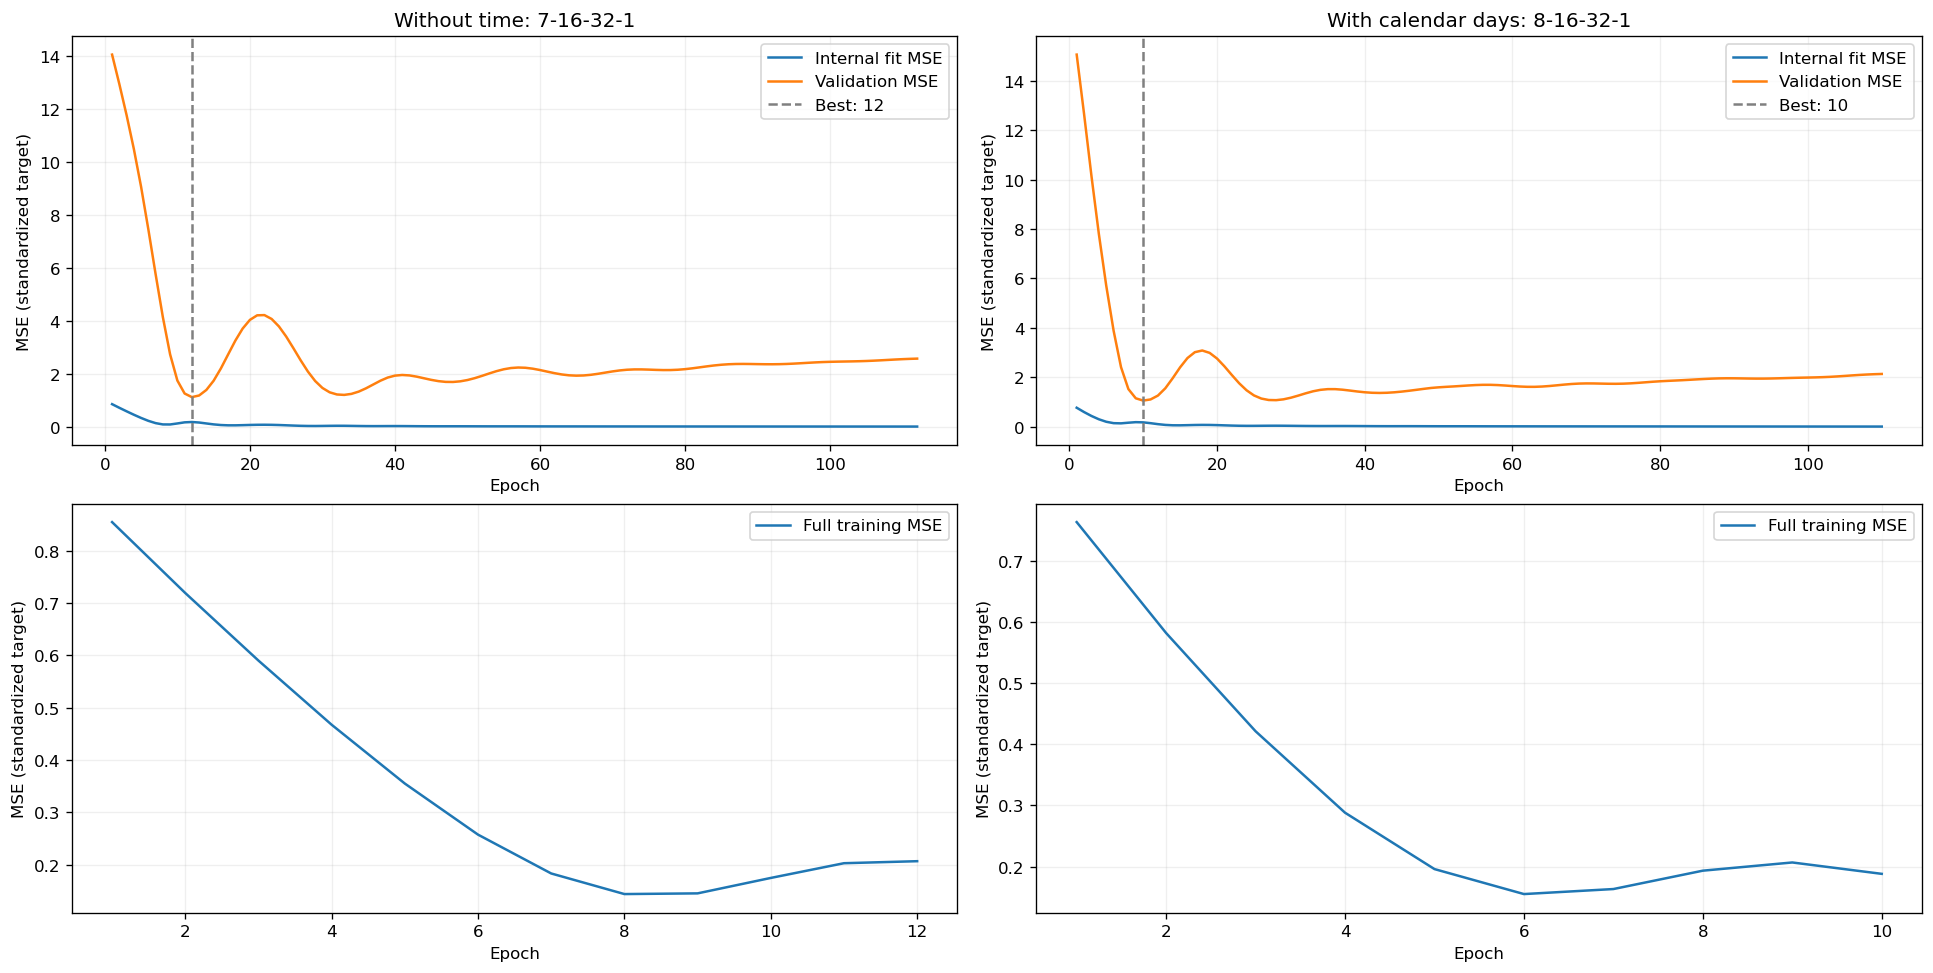

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
for j, (key, label) in enumerate([('base', 'Without time: 7-16-32-1'), ('time', 'With calendar days: 8-16-32-1')]):
    run = runs[key]
    h = run['history']
    axes[0, j].plot(h.epoch, h.fit_mse, label='Internal fit MSE')
    axes[0, j].plot(h.epoch, h.val_mse, label='Validation MSE')
    axes[0, j].axvline(run['best_epoch'], color='gray', linestyle='--', label=f'Best: {run["best_epoch"]}')
    axes[0, j].set_title(label)
    axes[1, j].plot(range(1, len(run['final_curve']) + 1), run['final_curve'], label='Full training MSE')
for ax in axes.flat:
    ax.set(xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mse_comparison.png', dpi=140)
plt.show()


## 3. 相同日期的误差比较

验证分数来自内部最佳模型；训练／测试分数来自完整训练集重训后的最终模型。RMSE、MAE使用原股价单位，R²不等于预测正确率。

In [ ]:
metric_rows = []
for key, run in runs.items():
    for split, idx, pred in [('Validation (internal best)', val_index, run['val_pred']),
                             ('Train (final)', train_index, run['preds']['Train']),
                             ('Test (final)', test_index, run['preds']['Test'])]:
        truth = np.asarray(Y.loc[idx]).ravel()
        pred = np.asarray(pred)
        mse = mean_squared_error(truth, pred)
        metric_rows.append({'模型': key, '评价段': split, '样本数': len(idx),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.abs(truth - pred).mean(), 'R²': r2_score(truth, pred)})
metrics = pd.DataFrame(metric_rows).set_index(['评价段', '模型']).sort_index()
display(metrics.round(4))
metrics.to_csv(OUT / 'metrics.csv')


样本数      MSE    RMSE     MAE      R²
评价段                        模型                                         
Test (final)               base   152  30.0512  5.4819  4.9294 -0.7544
                           time   152  38.1234  6.1744  5.4924 -1.2257
Train (final)              base  3685   7.3729  2.7153  2.0677  0.7936
                           time  3685   6.7188  2.5921  2.1009  0.8120
Validation (internal best) base   185  23.1950  4.8161  4.1062  0.2302
                           time   185  21.9410  4.6841  4.1599  0.2718

## 4. 最终模型训练／测试预测对比

两条预测线使用同一批日期。灰色区域是原内部验证段，已参与最终重训；紫色为最终测试集。

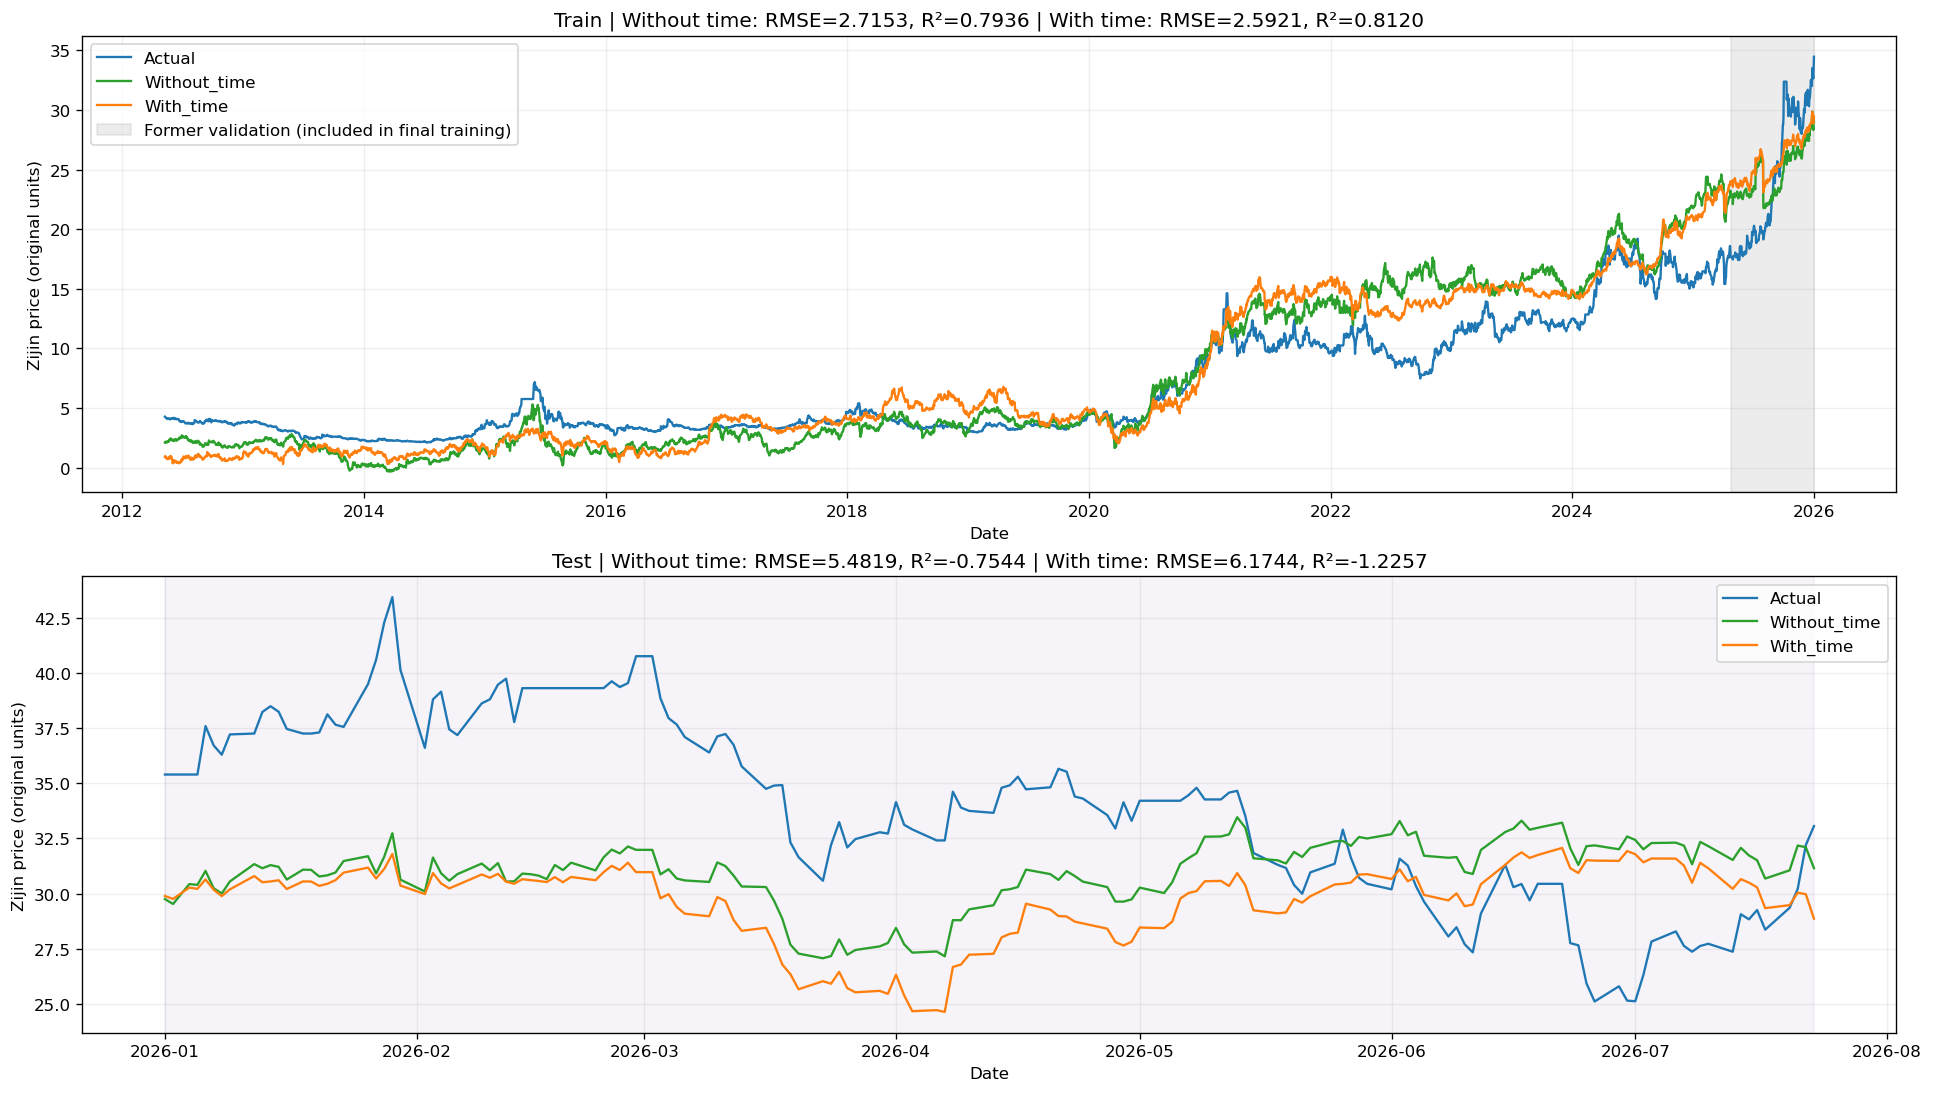

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split, idx in zip(axes, ['Train', 'Test'], [train_index, test_index]):
    frame = pd.DataFrame({'Actual': np.asarray(Y.loc[idx]).ravel(),
        'Without_time': runs['base']['preds'][split], 'With_time': runs['time']['preds'][split]}, index=idx)
    assert np.isfinite(frame.to_numpy()).all()
    frame.to_csv(OUT / f'{split.lower()}_predictions.csv')
    for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
        ax.plot(idx, frame[name], label=name, color=color, linewidth=1.4)
    if split == 'Train':
        ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final training)')
    else:
        ax.axvspan(idx.min(), idx.max(), color='tab:purple', alpha=0.08)
    a, b = metrics.loc[(split + ' (final)', 'base')], metrics.loc[(split + ' (final)', 'time')]
    ax.set(title=f'{split} | Without time: RMSE={a.RMSE:.4f}, R²={a["R²"]:.4f}'
        f' | With time: RMSE={b.RMSE:.4f}, R²={b["R²"]:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'prediction_comparison.png', dpi=140)
plt.show()


## 本次运行记录

| 模型   |   输入数 |   参数量 |   最佳轮数 |   停止轮数 |
|:-------|---------:|---------:|-----------:|-----------:|
| base   |        7 |      705 |         12 |        112 |
| time   |        8 |      721 |         10 |        110 |

|                                        |   样本数 |     MSE |   RMSE |    MAE |      R² |
|:---------------------------------------|---------:|--------:|-------:|-------:|--------:|
| ('Test (final)', 'base')               |      152 | 30.0512 | 5.4819 | 4.9294 | -0.7544 |
| ('Test (final)', 'time')               |      152 | 38.1234 | 6.1744 | 5.4924 | -1.2257 |
| ('Train (final)', 'base')              |     3685 |  7.3729 | 2.7153 | 2.0677 |  0.7936 |
| ('Train (final)', 'time')              |     3685 |  6.7188 | 2.5921 | 2.1009 |  0.812  |
| ('Validation (internal best)', 'base') |      185 | 23.195  | 4.8161 | 4.1062 |  0.2302 |
| ('Validation (internal best)', 'time') |      185 | 21.941  | 4.6841 | 4.1599 |  0.2718 |

时间因子以 **2012-05-09** 为1，跨周末按真实天数增加。原7因子模型有705个参数，增加一个输入后有721个参数。两组验证日期及测试日期完全相同，选定轮数由各自验证误差决定。本次是固定种子的一次比较，未检验初始化稳定性。

时间变量只提供时间位置，不会自动识别真实遗漏因素。相同种子也不代表不同输入维度的模型具有逐项相同的初始权重。测试段已在此前实验中查看过，因此结果属于探索性比较；沿用原始数据及同日解释股价口径。

图像、模型与标准化参数、预测明细保存在 `results/mlp_time_dimension_05/`；修改设置后需要同步更新以上记录。

# 新对照实验：复现03的一季度验证划分，比较实际日历天数

基准模型为 **7→16→32→1**；实验模型为 **8→16→32→1**，只新增一个 `elapsed_days` 因子：**(当前日期 − 整个数据集首日).days + 1**。首日为1，周末、节假日也计入经过的天数，不补造缺失日期的训练记录。

使用全部历史数据。**2025-12-31及以前为内部拟合集，2026-01-01至2026-03-31为内部验证集，2026-04-01及以后为测试集**。最终重新初始化，在截至2026-03-31的完整训练集上重训选定轮数。两组使用完全相同日期及目标。

保持 ReLU、Adam、LR=0.01、seed=42、2000轮上限、MIN_DELTA=1e-6、连续100轮验证误差未改善早停。各自选择最佳轮数后，重新初始化，在各自完整训练集重训。标准化只在相应拟合段学习参数，包括时间因子；时间计数原点始终固定为原数据首日。

时间趋势可能代理随时间变化的遗漏因素，但不能据此认定学到了产量等具体因果关系，也不保证未来趋势延续。本次不加入Lasso。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
OUT = ROOT / 'results/mlp_time_dimension_05_validation_2026q1'
OUT.mkdir(parents=True, exist_ok=True)
SEED, LR, MAX_EPOCHS, PATIENCE, MIN_DELTA = 42, 0.01, 2000, 100, 1e-6
VAL_START, TEST_START = pd.Timestamp('2026-01-01'), pd.Timestamp('2026-04-01')
torch.set_num_threads(1)
dataset_path = ROOT / 'src/pickle/Dataset.pkl'
dataset = pd.read_pickle(dataset_path)
X_base, Y = dataset['X'].copy(), dataset['Y'].copy()
assert X_base.index.equals(Y.index) and X_base.shape[1] == 7
assert isinstance(X_base.index, pd.DatetimeIndex)
assert X_base.index.is_unique and X_base.index.is_monotonic_increasing
assert np.isfinite(X_base.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
origin = X_base.index.min().normalize()
X_time = X_base.copy()
X_time['elapsed_days'] = (X_time.index.normalize() - origin).days + 1
assert X_time.elapsed_days.iloc[0] == 1
assert np.array_equal(np.diff(X_time.elapsed_days), np.diff(X_time.index.normalize().values).astype('timedelta64[D]').astype(int))
train_index = X_base.index[X_base.index < TEST_START]
test_index = X_base.index[X_base.index >= TEST_START]
fit_index = train_index[train_index < VAL_START]
val_index = train_index[train_index >= VAL_START]
assert fit_index.max() < val_index.min() <= val_index.max() < test_index.min()
split_info = pd.DataFrame([{'数据段': name, '记录数': len(idx), '开始': idx.min(), '结束': idx.max()}
    for name, idx in [('内部拟合集', fit_index), ('内部验证集', val_index),
                      ('完整训练集', train_index), ('测试集', test_index)]])
display(split_info)
print('时间计数原点：', origin.date())
display(X_time[['elapsed_days']].head(10))
# 原数据首日是周三：周五为3，下一周一为6，相隔3个实际日历日。
assert X_time.loc['2012-05-14', 'elapsed_days'] - X_time.loc['2012-05-11', 'elapsed_days'] == 3


时间计数原点： 2012-05-09


,数据段,记录数,开始,结束
0,内部拟合集,3685,2012-05-09,2025-12-31
1,内部验证集,69,2026-01-01,2026-03-31
2,完整训练集,3754,2012-05-09,2026-03-31
3,测试集,83,2026-04-01,2026-07-23


,elapsed_days
2012-05-09,1
2012-05-10,2
2012-05-11,3
2012-05-14,6
2012-05-15,7
2012-05-16,8
2012-05-17,9
2012-05-18,10
2012-05-21,13
2012-05-22,14


## 1. 两组使用相同训练流程

各自独立标准化、选轮并重训；验证与测试目标不会用于拟合标准化器。保存内部最佳权重和最终权重，两者配套的标准化器不同。

In [ ]:
def tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32)

def build_model(n_inputs):
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(n_inputs, 16), nn.ReLU(),
                         nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 1))

def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}

def train_variant(features, key):
    sx = StandardScaler().fit(features.loc[fit_index])
    sy = StandardScaler().fit(Y.loc[fit_index].to_numpy().reshape(-1, 1))
    xf, xv = tensor(sx.transform(features.loc[fit_index])), tensor(sx.transform(features.loc[val_index]))
    yf = tensor(sy.transform(Y.loc[fit_index].to_numpy().reshape(-1, 1)))
    yv = tensor(sy.transform(Y.loc[val_index].to_numpy().reshape(-1, 1)))
    candidate = build_model(features.shape[1])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(candidate.parameters(), lr=LR)
    best_loss, best_epoch, waiting, best_state = float('inf'), 0, 0, None
    rows = []
    for epoch in range(1, MAX_EPOCHS + 1):
        candidate.train()
        loss = loss_fn(candidate(xf), yf)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        candidate.eval()
        with torch.no_grad():
            fit_mse = loss_fn(candidate(xf), yf).item()
            val_mse = loss_fn(candidate(xv), yv).item()
        assert np.isfinite(fit_mse) and np.isfinite(val_mse)
        rows.append([epoch, fit_mse, val_mse])
        if val_mse < best_loss - MIN_DELTA:
            best_loss, best_epoch, waiting = val_mse, epoch, 0
            best_state = deepcopy(candidate.state_dict())
        else:
            waiting += 1
        if waiting >= PATIENCE:
            break
    stopped_epoch = epoch
    candidate.load_state_dict(best_state)
    candidate.eval()
    with torch.no_grad():
        assert np.isclose(loss_fn(candidate(xv), yv).item(), best_loss)
        val_pred = sy.inverse_transform(candidate(xv).numpy()).ravel()
    sx_final = StandardScaler().fit(features.loc[train_index])
    sy_final = StandardScaler().fit(Y.loc[train_index].to_numpy().reshape(-1, 1))
    xt = tensor(sx_final.transform(features.loc[train_index]))
    yt = tensor(sy_final.transform(Y.loc[train_index].to_numpy().reshape(-1, 1)))
    model = build_model(features.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    final_curve = []
    for epoch in range(1, best_epoch + 1):
        model.train()
        loss = loss_fn(model(xt), yt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            final_curve.append(loss_fn(model(xt), yt).item())
    assert np.isfinite(final_curve).all()
    preds = {}
    for split, idx in [('Train', train_index), ('Test', test_index)]:
        with torch.no_grad():
            pred = sy_final.inverse_transform(model(tensor(sx_final.transform(features.loc[idx]))).numpy()).ravel()
        preds[split] = pd.Series(pred, index=idx)
    history = pd.DataFrame(rows, columns=['epoch', 'fit_mse', 'val_mse'])
    history.to_csv(OUT / f'{key}_selection_history.csv', index=False)
    torch.save({'model_state_dict': model.state_dict(), 'internal_best_state_dict': best_state,
        'n_inputs': features.shape[1], 'hidden_layers': [16, 32], 'feature_names': list(features.columns),
        'origin': str(origin.date()), 'time_formula': '(date - origin).days + 1',
        'scaler_x_internal': scaler_state(sx), 'scaler_y_internal': scaler_state(sy),
        'scaler_x_final': scaler_state(sx_final), 'scaler_y_final': scaler_state(sy_final),
        'best_epoch': best_epoch, 'stopped_epoch': stopped_epoch,
        'seed': SEED, 'lr': LR, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
        'test_start': str(TEST_START.date()), 'validation_start': str(VAL_START.date()), 'validation_end_exclusive': str(TEST_START.date()),
        'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()}, OUT / f'{key}_checkpoint.pt')
    return {'model': model, 'history': history, 'final_curve': final_curve, 'preds': preds,
            'val_pred': val_pred, 'best_epoch': best_epoch, 'stopped_epoch': stopped_epoch}

runs = {'base': train_variant(X_base, 'base'), 'time': train_variant(X_time, 'time')}
selection = pd.DataFrame([{'模型': key, '输入数': 7 if key == 'base' else 8,
    '参数量': sum(p.numel() for p in run['model'].parameters()),
    '最佳轮数': run['best_epoch'], '停止轮数': run['stopped_epoch']}
    for key, run in runs.items()])
display(selection)


,模型,输入数,参数量,最佳轮数,停止轮数
0,base,7,705,76,176
1,time,8,721,183,283


## 2. MSE 曲线

两组的目标标准化使用相同样本，因此同一阶段的目标尺度一致。上排为内部拟合／验证 MSE，下排为完整训练重训 MSE。

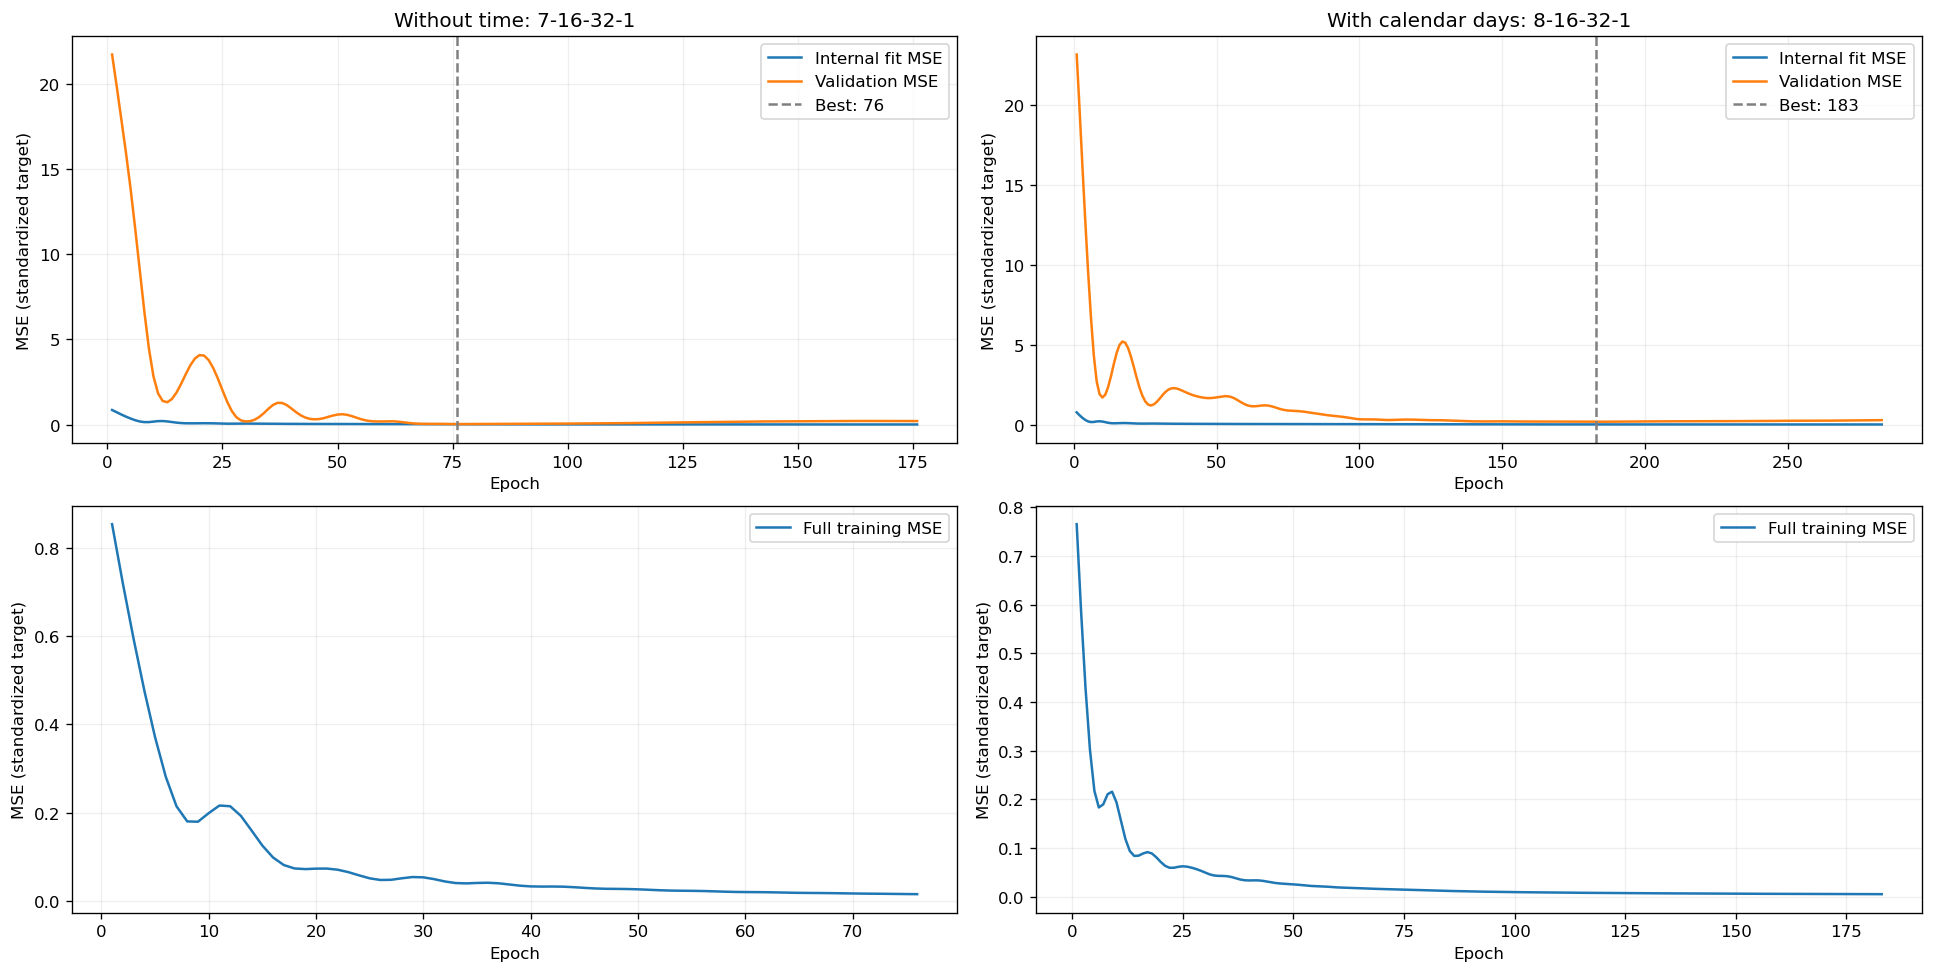

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
for j, (key, label) in enumerate([('base', 'Without time: 7-16-32-1'), ('time', 'With calendar days: 8-16-32-1')]):
    run = runs[key]
    h = run['history']
    axes[0, j].plot(h.epoch, h.fit_mse, label='Internal fit MSE')
    axes[0, j].plot(h.epoch, h.val_mse, label='Validation MSE')
    axes[0, j].axvline(run['best_epoch'], color='gray', linestyle='--', label=f'Best: {run["best_epoch"]}')
    axes[0, j].set_title(label)
    axes[1, j].plot(range(1, len(run['final_curve']) + 1), run['final_curve'], label='Full training MSE')
for ax in axes.flat:
    ax.set(xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mse_comparison.png', dpi=140)
plt.show()


## 3. 相同日期的误差比较

验证分数来自内部最佳模型；训练／测试分数来自完整训练集重训后的最终模型。RMSE、MAE使用原股价单位，R²不等于预测正确率。

In [ ]:
metric_rows = []
for key, run in runs.items():
    for split, idx, pred in [('Validation (internal best)', val_index, run['val_pred']),
                             ('Train (final)', train_index, run['preds']['Train']),
                             ('Test (final)', test_index, run['preds']['Test'])]:
        truth = np.asarray(Y.loc[idx]).ravel()
        pred = np.asarray(pred)
        mse = mean_squared_error(truth, pred)
        metric_rows.append({'模型': key, '评价段': split, '样本数': len(idx),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.abs(truth - pred).mean(), 'R²': r2_score(truth, pred)})
metrics = pd.DataFrame(metric_rows).set_index(['评价段', '模型']).sort_index()
display(metrics.round(4))
metrics.to_csv(OUT / 'metrics.csv')


样本数      MSE    RMSE     MAE      R²
评价段                        模型                                         
Test (final)               base    83  64.3132  8.0196  7.5204 -6.5592
                           time    83  20.7827  4.5588  3.7418 -1.4427
Train (final)              base  3754   0.7731  0.8793  0.5404  0.9849
                           time  3754   0.2866  0.5353  0.3714  0.9944
Validation (internal best) base    69   0.9716  0.9857  0.7630  0.8555
                           time    69   6.1665  2.4833  2.2349  0.0831

## 4. 最终模型训练／测试预测对比

两条预测线使用同一批日期。灰色区域是原内部验证段，已参与最终重训；紫色为最终测试集。

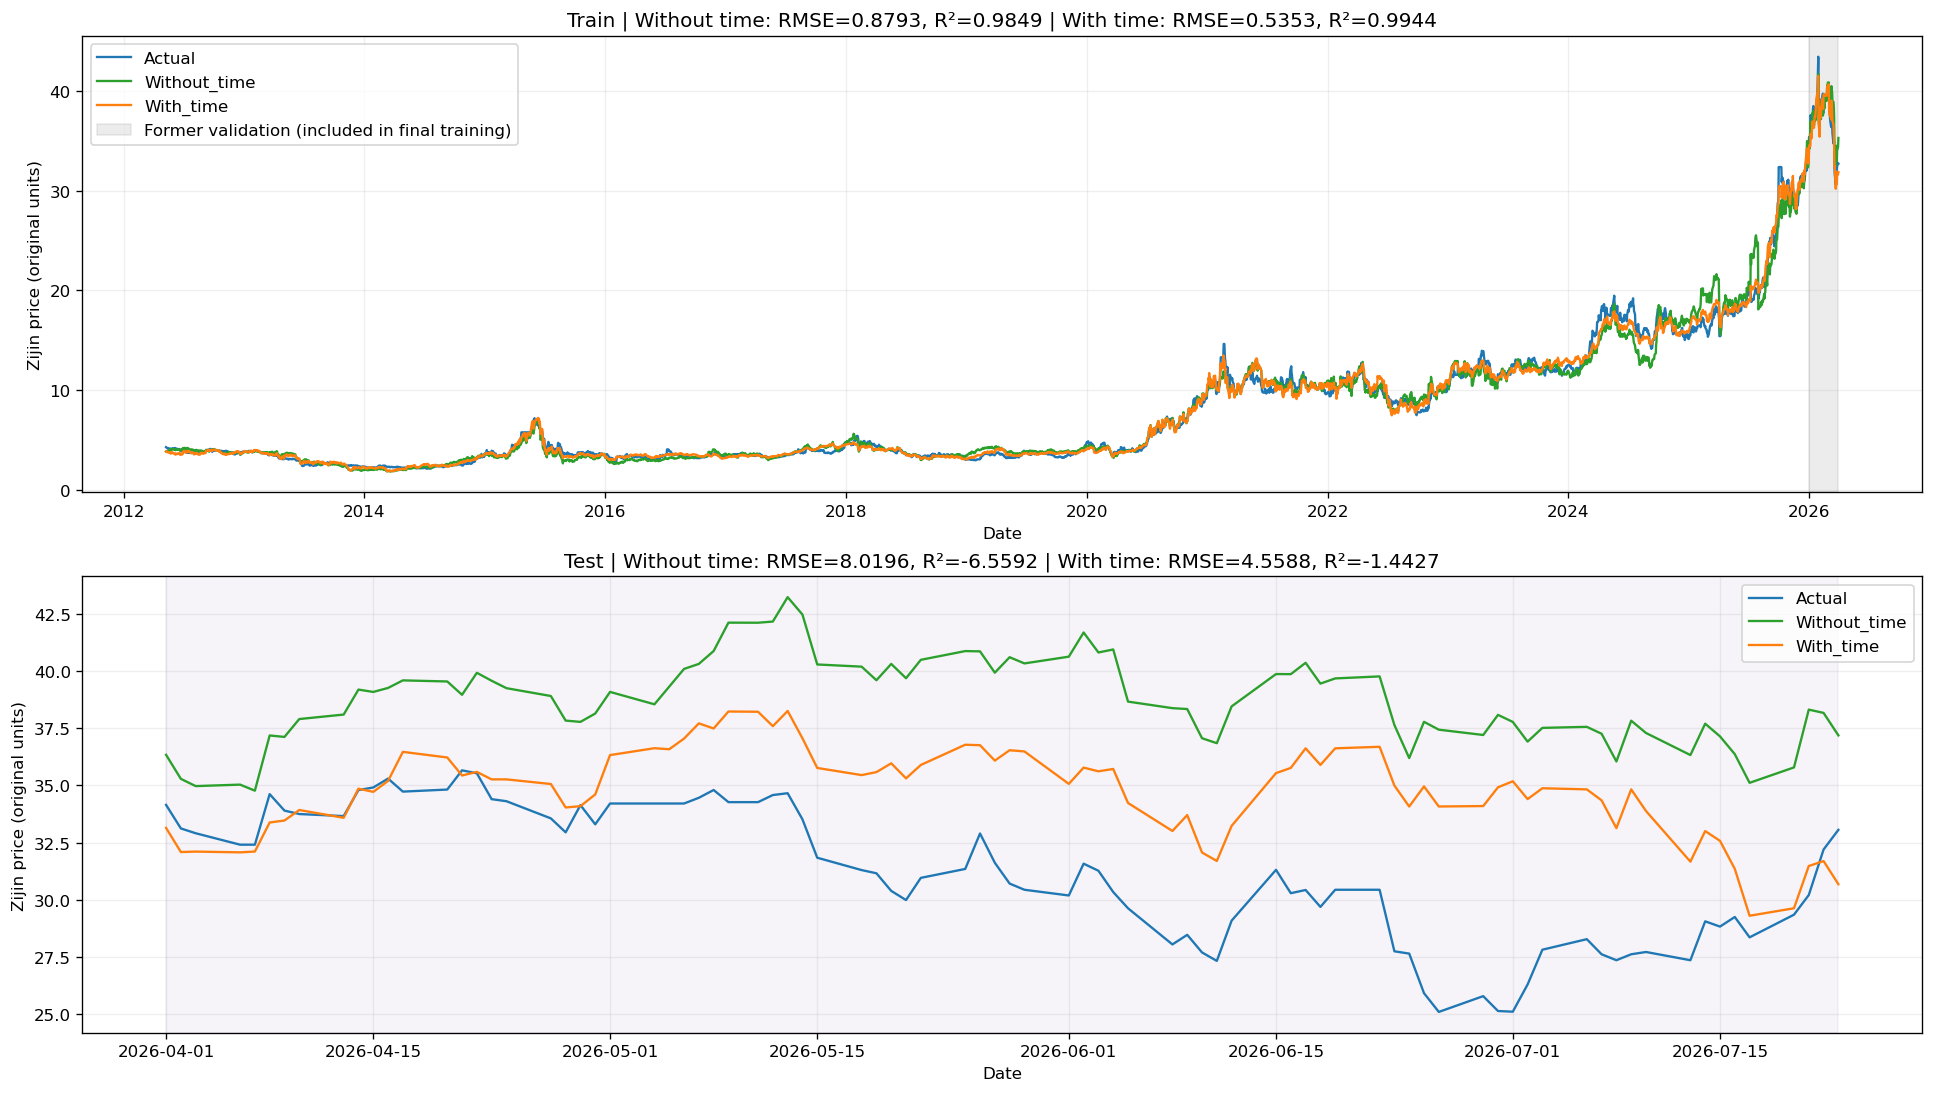

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split, idx in zip(axes, ['Train', 'Test'], [train_index, test_index]):
    frame = pd.DataFrame({'Actual': np.asarray(Y.loc[idx]).ravel(),
        'Without_time': runs['base']['preds'][split], 'With_time': runs['time']['preds'][split]}, index=idx)
    assert np.isfinite(frame.to_numpy()).all()
    frame.to_csv(OUT / f'{split.lower()}_predictions.csv')
    for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
        ax.plot(idx, frame[name], label=name, color=color, linewidth=1.4)
    if split == 'Train':
        ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final training)')
    else:
        ax.axvspan(idx.min(), idx.max(), color='tab:purple', alpha=0.08)
    a, b = metrics.loc[(split + ' (final)', 'base')], metrics.loc[(split + ' (final)', 'time')]
    ax.set(title=f'{split} | Without time: RMSE={a.RMSE:.4f}, R²={a["R²"]:.4f}'
        f' | With time: RMSE={b.RMSE:.4f}, R²={b["R²"]:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'prediction_comparison.png', dpi=140)
plt.show()


## 5. 单独放大2024-01-01至2026-03-31

两组最终模型在同一段日期比较。灰色一季度已参与最终重训，图中该段误差属于训练误差，不是独立验证误差；独立验证误差见前面的指标表。


,N,MSE,RMSE,R2
Model,,,,
Without_time,610,3.6079,1.8994,0.9388
With_time,610,0.8735,0.9346,0.9852


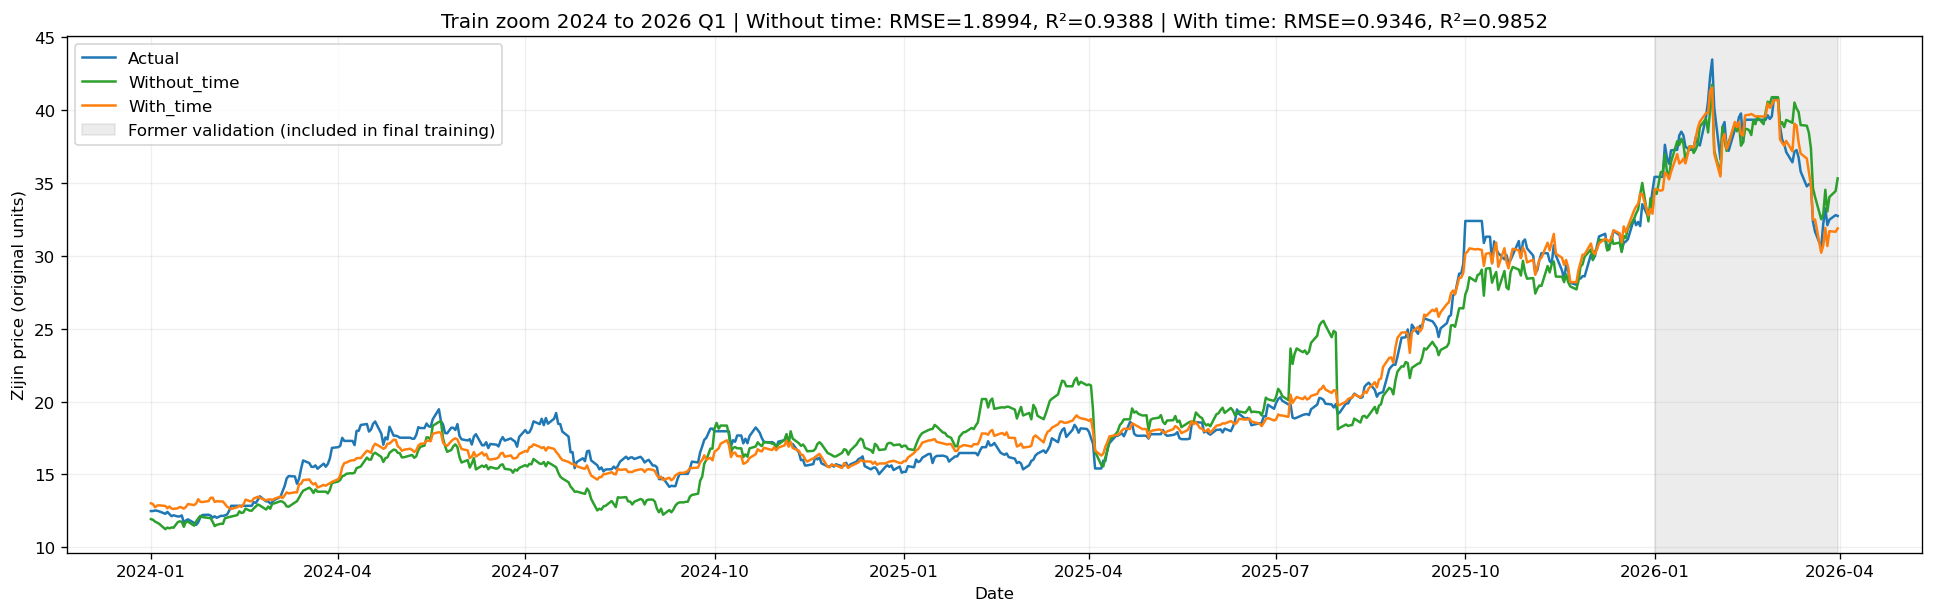

In [ ]:
zoom_index = train_index[(train_index >= '2024-01-01') & (train_index < '2026-04-01')]
zoom = pd.DataFrame({'Actual': np.asarray(Y.loc[zoom_index]).ravel(),
    'Without_time': runs['base']['preds']['Train'].loc[zoom_index],
    'With_time': runs['time']['preds']['Train'].loc[zoom_index]}, index=zoom_index)
zoom_metrics = pd.DataFrame([{'Model': name, 'N': len(zoom),
    'MSE': mean_squared_error(zoom.Actual, zoom[name]),
    'RMSE': np.sqrt(mean_squared_error(zoom.Actual, zoom[name])),
    'R2': r2_score(zoom.Actual, zoom[name])} for name in ['Without_time', 'With_time']]).set_index('Model')
display(zoom_metrics.round(4))
zoom.to_csv(OUT / 'train_zoom_predictions.csv')
zoom_metrics.to_csv(OUT / 'train_zoom_metrics.csv')
fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)
for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
    ax.plot(zoom.index, zoom[name], color=color, label=name)
ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
    label='Former validation (included in final training)')
a, b = zoom_metrics.loc['Without_time'], zoom_metrics.loc['With_time']
ax.set(title=f'Train zoom 2024 to 2026 Q1 | Without time: RMSE={a.RMSE:.4f}, R²={a.R2:.4f}'
    f' | With time: RMSE={b.RMSE:.4f}, R²={b.R2:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
ax.grid(alpha=0.2)
ax.legend()
fig.savefig(OUT / 'train_zoom.png', dpi=140)
plt.show()


## 本次运行记录（2026年一季度验证）

**无时间基准的逐轮拟合／验证MSE已与03原实验核对一致：最佳76轮，停止176轮。** 旧05选择12轮并不代表训练已收敛：早停依据是验证MSE，最后再在完整训练集重训12轮。新划分更改了内部拟合样本、标准化参数及验证目标，不能把差别只理解为时间轴移动。增加日历天数仍然是普通MLP，不是循环网络。


| 模型   |   输入数 |   参数量 |   最佳轮数 |   停止轮数 |
|:-------|---------:|---------:|-----------:|-----------:|
| base   |        7 |      705 |         76 |        176 |
| time   |        8 |      721 |        183 |        283 |

|                                        |   样本数 |     MSE |   RMSE |    MAE |      R² |
|:---------------------------------------|---------:|--------:|-------:|-------:|--------:|
| ('Test (final)', 'base')               |       83 | 64.3132 | 8.0196 | 7.5204 | -6.5592 |
| ('Test (final)', 'time')               |       83 | 20.7827 | 4.5588 | 3.7418 | -1.4427 |
| ('Train (final)', 'base')              |     3754 |  0.7731 | 0.8793 | 0.5404 |  0.9849 |
| ('Train (final)', 'time')              |     3754 |  0.2866 | 0.5353 | 0.3714 |  0.9944 |
| ('Validation (internal best)', 'base') |       69 |  0.9716 | 0.9857 | 0.763  |  0.8555 |
| ('Validation (internal best)', 'time') |       69 |  6.1665 | 2.4833 | 2.2349 |  0.0831 |

时间因子以 **2012-05-09** 为1，跨周末按真实天数增加。原7因子模型有705个参数，增加一个输入后有721个参数。两组验证日期及测试日期完全相同，选定轮数由各自验证误差决定。本次是固定种子的一次比较，未检验初始化稳定性。

时间变量只提供时间位置，不会自动识别真实遗漏因素。相同种子也不代表不同输入维度的模型具有逐项相同的初始权重。测试段已在此前实验中查看过，因此结果属于探索性比较；沿用原始数据及同日解释股价口径。

图像、模型与标准化参数、预测明细保存在 `results/mlp_time_dimension_05_validation_2026q1/`；修改设置后需要同步更新以上记录。

---

加入了时间维度以后,原来模型中突然的暴跌没有了.模型有很大的改善,这应该作为一个保留时间维度的理由.  
对于我们的验证集,我们也可以看到加入了时间维度更贴近实际值.  
一开始的数据集的划分,我划分的不够好,没有充分考虑到自变量的变化范围,训练一直不收敛.

针对加入时间维度后,模型的效果,我们采取多轮测试.以数据范围稳定为前提,用不同的时间段来验证这个结论.

我们选用16-17年,18-19年,20-21年,22-23年四个阶段进行测试.数据集的划分还是同理.并在最后将四个阶段的RMSE与R^2保留下来,并取平均得到最后的结果.

---

# 四个历史测试阶段：检验日历时间特征

测试期分别为 **2016—2017、2018—2019、2020—2021、2022—2023完整两个自然年**，右边界为下一年1月1日且不包含该日。各阶段完整训练集使用原数据首日至测试开始前的全部记录；其末尾**三个自然月**作为内部验证期，沿用上一节固定三个月验证规则（不是5%划分）。例如2016—2017测试对应2015年10—12月验证。

每个阶段分别比较7→16→32→1与8→16→32→1，唯一新增输入是原始首日起的实际日历天数。沿用seed=42、Adam学习率0.01、2000轮上限、验证MSE改善阈值1e-6、连续100轮未改善早停；分别选轮后重新初始化，在完整训练集重训选定轮数。测试期不参与标准化、选轮或训练。

以下公共准备块先执行；每阶段依次执行训练、MSE、预测图三个代码块。最后对四阶段**测试**RMSE与R²做等权算术平均，不把训练或验证分数混入平均；分期R²的平均不等于合并样本的R²。结果用于判断是否支持保留时间特征，不预设结论。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
OUT = ROOT / 'results/mlp_time_dimension_05_four_periods'
OUT.mkdir(parents=True, exist_ok=True)
SEED, LR, MAX_EPOCHS, PATIENCE, MIN_DELTA = 42, 0.01, 2000, 100, 1e-6
VAL_START, TEST_START = pd.Timestamp('2026-01-01'), pd.Timestamp('2026-04-01')
torch.set_num_threads(1)
dataset_path = ROOT / 'src/pickle/Dataset.pkl'
dataset = pd.read_pickle(dataset_path)
X_base, Y = dataset['X'].copy(), dataset['Y'].copy()
assert X_base.index.equals(Y.index) and X_base.shape[1] == 7
assert isinstance(X_base.index, pd.DatetimeIndex)
assert X_base.index.is_unique and X_base.index.is_monotonic_increasing
assert np.isfinite(X_base.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
origin = X_base.index.min().normalize()
X_time = X_base.copy()
X_time['elapsed_days'] = (X_time.index.normalize() - origin).days + 1
assert X_time.elapsed_days.iloc[0] == 1
assert np.array_equal(np.diff(X_time.elapsed_days), np.diff(X_time.index.normalize().values).astype('timedelta64[D]').astype(int))

EXPERIMENT_OUT = OUT
stage_results = {}

def tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32)

def build_model(n_inputs):
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(n_inputs, 16), nn.ReLU(),
                         nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 1))

def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}

def train_variant(features, key):
    sx = StandardScaler().fit(features.loc[fit_index])
    sy = StandardScaler().fit(Y.loc[fit_index].to_numpy().reshape(-1, 1))
    xf, xv = tensor(sx.transform(features.loc[fit_index])), tensor(sx.transform(features.loc[val_index]))
    yf = tensor(sy.transform(Y.loc[fit_index].to_numpy().reshape(-1, 1)))
    yv = tensor(sy.transform(Y.loc[val_index].to_numpy().reshape(-1, 1)))
    candidate = build_model(features.shape[1])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(candidate.parameters(), lr=LR)
    best_loss, best_epoch, waiting, best_state = float('inf'), 0, 0, None
    rows = []
    for epoch in range(1, MAX_EPOCHS + 1):
        candidate.train()
        loss = loss_fn(candidate(xf), yf)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        candidate.eval()
        with torch.no_grad():
            fit_mse = loss_fn(candidate(xf), yf).item()
            val_mse = loss_fn(candidate(xv), yv).item()
        assert np.isfinite(fit_mse) and np.isfinite(val_mse)
        rows.append([epoch, fit_mse, val_mse])
        if val_mse < best_loss - MIN_DELTA:
            best_loss, best_epoch, waiting = val_mse, epoch, 0
            best_state = deepcopy(candidate.state_dict())
        else:
            waiting += 1
        if waiting >= PATIENCE:
            break
    stopped_epoch = epoch
    candidate.load_state_dict(best_state)
    candidate.eval()
    with torch.no_grad():
        assert np.isclose(loss_fn(candidate(xv), yv).item(), best_loss)
        val_pred = sy.inverse_transform(candidate(xv).numpy()).ravel()
    sx_final = StandardScaler().fit(features.loc[train_index])
    sy_final = StandardScaler().fit(Y.loc[train_index].to_numpy().reshape(-1, 1))
    xt = tensor(sx_final.transform(features.loc[train_index]))
    yt = tensor(sy_final.transform(Y.loc[train_index].to_numpy().reshape(-1, 1)))
    model = build_model(features.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    final_curve = []
    for epoch in range(1, best_epoch + 1):
        model.train()
        loss = loss_fn(model(xt), yt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            final_curve.append(loss_fn(model(xt), yt).item())
    assert np.isfinite(final_curve).all()
    preds = {}
    for split, idx in [('Train', train_index), ('Test', test_index)]:
        with torch.no_grad():
            pred = sy_final.inverse_transform(model(tensor(sx_final.transform(features.loc[idx]))).numpy()).ravel()
        preds[split] = pd.Series(pred, index=idx)
    history = pd.DataFrame(rows, columns=['epoch', 'fit_mse', 'val_mse'])
    history.to_csv(OUT / f'{key}_selection_history.csv', index=False)
    torch.save({'model_state_dict': model.state_dict(), 'internal_best_state_dict': best_state,
        'n_inputs': features.shape[1], 'hidden_layers': [16, 32], 'feature_names': list(features.columns),
        'origin': str(origin.date()), 'time_formula': '(date - origin).days + 1',
        'scaler_x_internal': scaler_state(sx), 'scaler_y_internal': scaler_state(sy),
        'scaler_x_final': scaler_state(sx_final), 'scaler_y_final': scaler_state(sy_final),
        'best_epoch': best_epoch, 'stopped_epoch': stopped_epoch,
        'seed': SEED, 'lr': LR, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
        'test_start': str(TEST_START.date()), 'test_end_exclusive': str(TEST_END.date()), 'validation_start': str(VAL_START.date()), 'validation_end_exclusive': str(TEST_START.date()),
        'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()}, OUT / f'{key}_checkpoint.pt')
    return {'model': model, 'history': history, 'final_curve': final_curve, 'preds': preds,
            'val_pred': val_pred, 'best_epoch': best_epoch, 'stopped_epoch': stopped_epoch}



## 测试阶段：2016-2017

内部验证：2015-10-01至2015-12-31；最终训练截至2015年底，测试截至2017年底。

In [ ]:
STAGE = '2016-2017'
TEST_START, TEST_END = pd.Timestamp('2016-01-01'), pd.Timestamp('2018-01-01')
VAL_START = TEST_START - pd.DateOffset(months=3)
OUT = EXPERIMENT_OUT / STAGE
OUT.mkdir(parents=True, exist_ok=True)
train_index = X_base.index[X_base.index < TEST_START]
fit_index = train_index[train_index < VAL_START]
val_index = train_index[train_index >= VAL_START]
test_index = X_base.index[(X_base.index >= TEST_START) & (X_base.index < TEST_END)]
assert len(fit_index) and len(val_index) and len(test_index)
assert fit_index.max() < val_index.min() <= val_index.max() < test_index.min()
split_info = pd.DataFrame([{'Split': name, 'N': len(idx), 'Start': idx.min(), 'End': idx.max()}
    for name, idx in [('Fit', fit_index), ('Validation', val_index), ('Train', train_index), ('Test', test_index)]])
display(split_info)
split_info.to_csv(OUT / 'split_info.csv', index=False)
runs = {'base': train_variant(X_base, 'base'), 'time': train_variant(X_time, 'time')}
selection = pd.DataFrame([{'模型': key, '输入数': 7 if key == 'base' else 8,
    '参数量': sum(p.numel() for p in run['model'].parameters()),
    '最佳轮数': run['best_epoch'], '停止轮数': run['stopped_epoch']}
    for key, run in runs.items()])
display(selection)

metric_rows = []
for key, run in runs.items():
    for split, idx, pred in [('Validation (internal best)', val_index, run['val_pred']),
                             ('Train (final)', train_index, run['preds']['Train']),
                             ('Test (final)', test_index, run['preds']['Test'])]:
        truth = np.asarray(Y.loc[idx]).ravel()
        pred = np.asarray(pred)
        mse = mean_squared_error(truth, pred)
        metric_rows.append({'模型': key, '评价段': split, '样本数': len(idx),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.abs(truth - pred).mean(), 'R²': r2_score(truth, pred)})
metrics = pd.DataFrame(metric_rows).set_index(['评价段', '模型']).sort_index()
display(metrics.round(4))
metrics.to_csv(OUT / 'metrics.csv')

selection.to_csv(OUT / 'selection.csv', index=False)
stage_results[STAGE] = {'metrics': metrics.copy(), 'selection': selection.copy()}


,Split,N,Start,End
0,Fit,912,2012-05-09,2015-09-30
1,Validation,67,2015-10-01,2015-12-31
2,Train,979,2012-05-09,2015-12-31
3,Test,535,2016-01-01,2017-12-31


,模型,输入数,参数量,最佳轮数,停止轮数
0,base,7,705,2,102
1,time,8,721,2,102


样本数     MSE    RMSE     MAE      R²
评价段                        模型                                       
Test (final)               base  535  0.0798  0.2825  0.2216  0.0646
                           time  535  0.1021  0.3195  0.2725 -0.1968
Train (final)              base  979  0.6872  0.8289  0.6433  0.2197
                           time  979  0.6729  0.8203  0.6409  0.2359
Validation (internal best) base   67  0.0149  0.1219  0.1056 -0.1862
                           time   67  0.0152  0.1231  0.1078 -0.2093

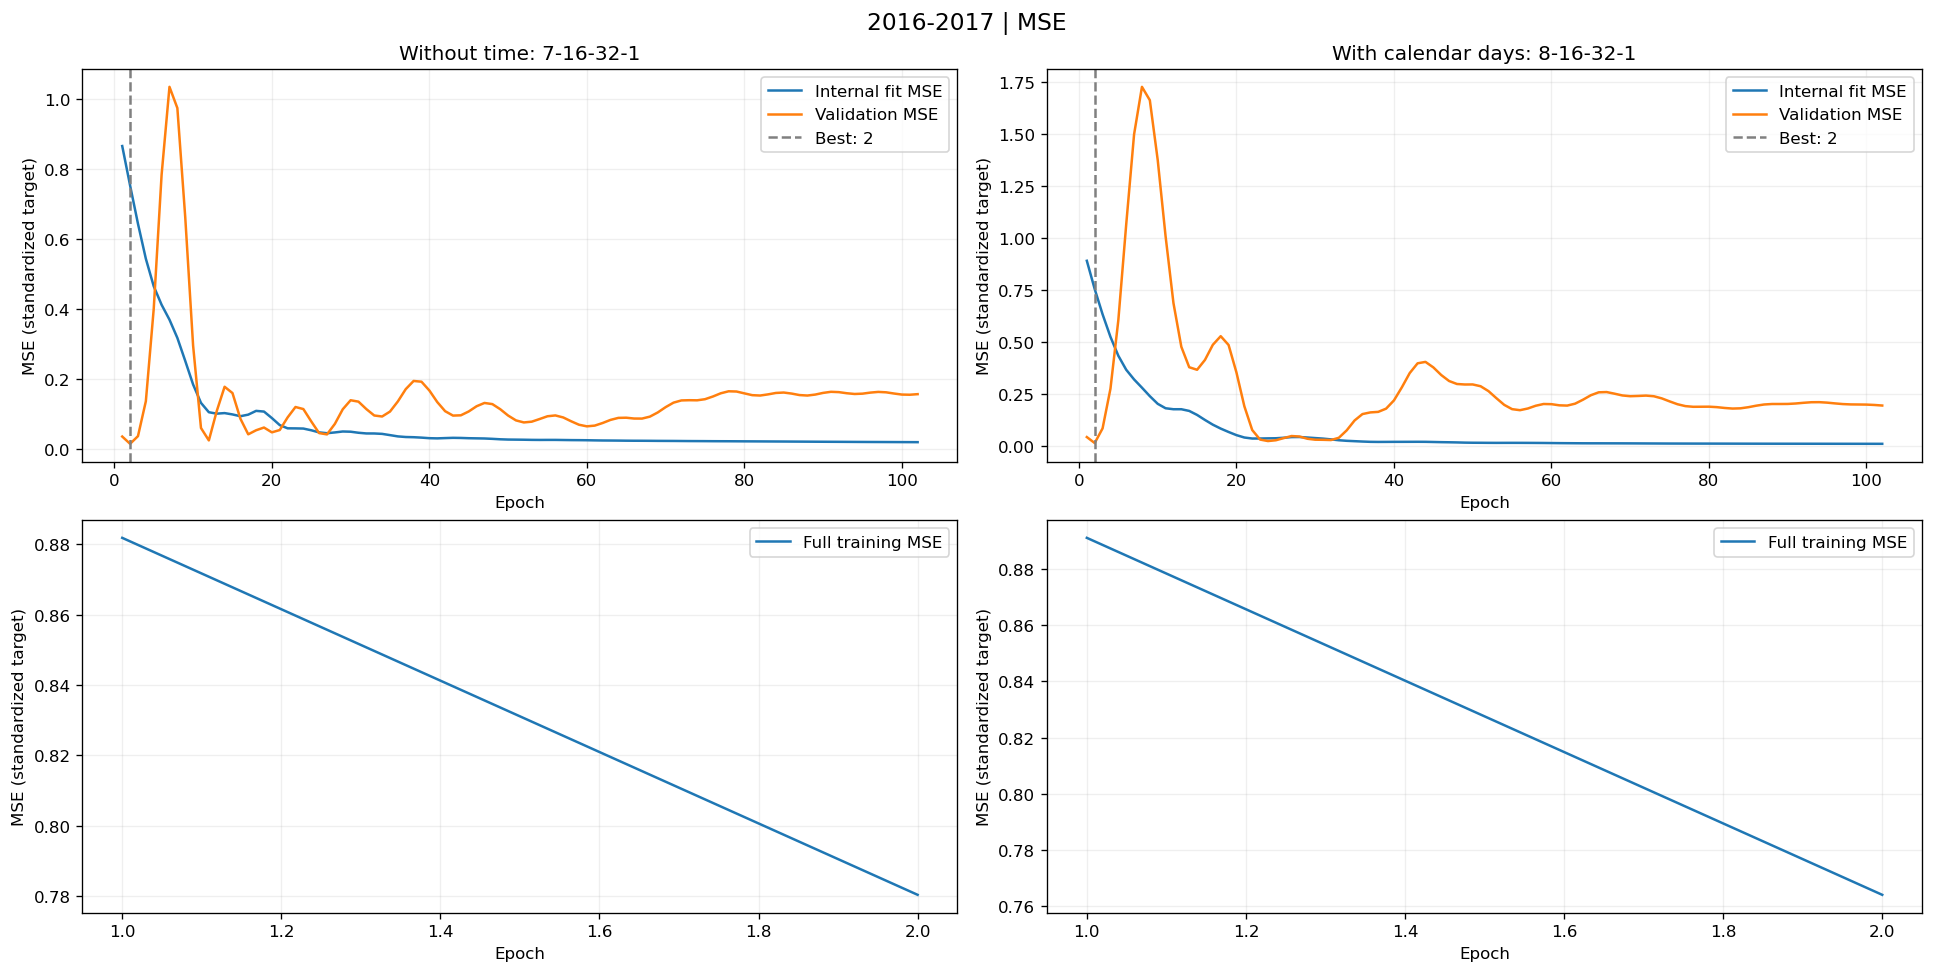

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
for j, (key, label) in enumerate([('base', 'Without time: 7-16-32-1'), ('time', 'With calendar days: 8-16-32-1')]):
    run = runs[key]
    h = run['history']
    axes[0, j].plot(h.epoch, h.fit_mse, label='Internal fit MSE')
    axes[0, j].plot(h.epoch, h.val_mse, label='Validation MSE')
    axes[0, j].axvline(run['best_epoch'], color='gray', linestyle='--', label=f'Best: {run["best_epoch"]}')
    axes[0, j].set_title(label)
    axes[1, j].plot(range(1, len(run['final_curve']) + 1), run['final_curve'], label='Full training MSE')
for ax in axes.flat:
    ax.set(xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle(STAGE + ' | MSE', fontsize=14)
fig.savefig(OUT / 'mse_comparison.png', dpi=140)
plt.show()


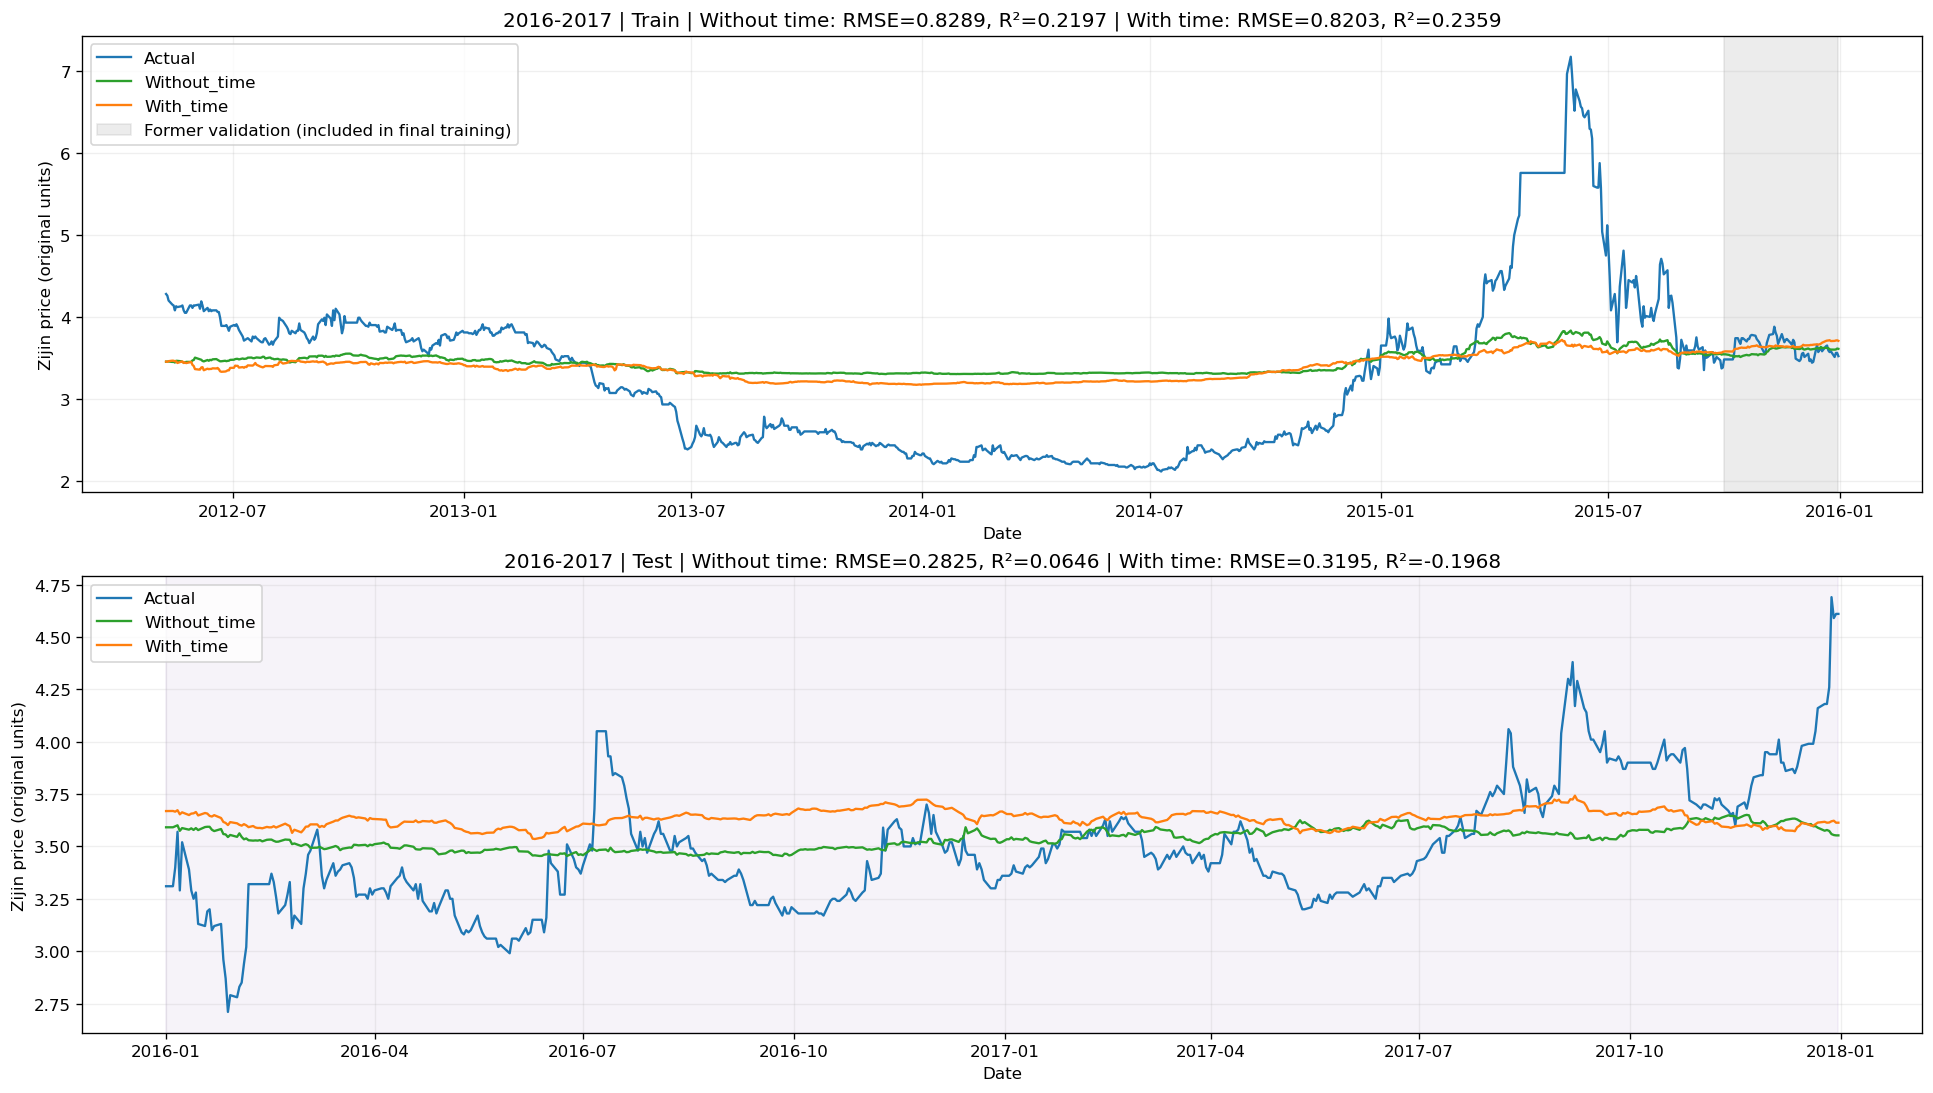

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split, idx in zip(axes, ['Train', 'Test'], [train_index, test_index]):
    frame = pd.DataFrame({'Actual': np.asarray(Y.loc[idx]).ravel(),
        'Without_time': runs['base']['preds'][split], 'With_time': runs['time']['preds'][split]}, index=idx)
    assert np.isfinite(frame.to_numpy()).all()
    frame.to_csv(OUT / f'{split.lower()}_predictions.csv')
    for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
        ax.plot(idx, frame[name], label=name, color=color, linewidth=1.4)
    if split == 'Train':
        ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final training)')
    else:
        ax.axvspan(idx.min(), idx.max(), color='tab:purple', alpha=0.08)
    a, b = metrics.loc[(split + ' (final)', 'base')], metrics.loc[(split + ' (final)', 'time')]
    ax.set(title=f'{STAGE} | {split} | Without time: RMSE={a.RMSE:.4f}, R²={a["R²"]:.4f}'
        f' | With time: RMSE={b.RMSE:.4f}, R²={b["R²"]:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'prediction_comparison.png', dpi=140)
plt.show()


## 测试阶段：2018-2019

内部验证：2017-10-01至2017-12-31；最终训练截至2017年底，测试截至2019年底。

In [ ]:
STAGE = '2018-2019'
TEST_START, TEST_END = pd.Timestamp('2018-01-01'), pd.Timestamp('2020-01-01')
VAL_START = TEST_START - pd.DateOffset(months=3)
OUT = EXPERIMENT_OUT / STAGE
OUT.mkdir(parents=True, exist_ok=True)
train_index = X_base.index[X_base.index < TEST_START]
fit_index = train_index[train_index < VAL_START]
val_index = train_index[train_index >= VAL_START]
test_index = X_base.index[(X_base.index >= TEST_START) & (X_base.index < TEST_END)]
assert len(fit_index) and len(val_index) and len(test_index)
assert fit_index.max() < val_index.min() <= val_index.max() < test_index.min()
split_info = pd.DataFrame([{'Split': name, 'N': len(idx), 'Start': idx.min(), 'End': idx.max()}
    for name, idx in [('Fit', fit_index), ('Validation', val_index), ('Train', train_index), ('Test', test_index)]])
display(split_info)
split_info.to_csv(OUT / 'split_info.csv', index=False)
runs = {'base': train_variant(X_base, 'base'), 'time': train_variant(X_time, 'time')}
selection = pd.DataFrame([{'模型': key, '输入数': 7 if key == 'base' else 8,
    '参数量': sum(p.numel() for p in run['model'].parameters()),
    '最佳轮数': run['best_epoch'], '停止轮数': run['stopped_epoch']}
    for key, run in runs.items()])
display(selection)

metric_rows = []
for key, run in runs.items():
    for split, idx, pred in [('Validation (internal best)', val_index, run['val_pred']),
                             ('Train (final)', train_index, run['preds']['Train']),
                             ('Test (final)', test_index, run['preds']['Test'])]:
        truth = np.asarray(Y.loc[idx]).ravel()
        pred = np.asarray(pred)
        mse = mean_squared_error(truth, pred)
        metric_rows.append({'模型': key, '评价段': split, '样本数': len(idx),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.abs(truth - pred).mean(), 'R²': r2_score(truth, pred)})
metrics = pd.DataFrame(metric_rows).set_index(['评价段', '模型']).sort_index()
display(metrics.round(4))
metrics.to_csv(OUT / 'metrics.csv')

selection.to_csv(OUT / 'selection.csv', index=False)
stage_results[STAGE] = {'metrics': metrics.copy(), 'selection': selection.copy()}


,Split,N,Start,End
0,Fit,1447,2012-05-09,2017-09-30
1,Validation,67,2017-10-02,2017-12-31
2,Train,1514,2012-05-09,2017-12-31
3,Test,540,2018-01-01,2019-12-31


,模型,输入数,参数量,最佳轮数,停止轮数
0,base,7,705,6,106
1,time,8,721,12,112


样本数     MSE    RMSE     MAE      R²
评价段                        模型                                        
Test (final)               base   540  0.2042  0.4519  0.3258  0.1476
                           time   540  0.2377  0.4876  0.4021  0.0078
Train (final)              base  1514  0.3124  0.5589  0.4110  0.4848
                           time  1514  0.1466  0.3829  0.2592  0.7581
Validation (internal best) base    67  0.0713  0.2671  0.1967 -0.3939
                           time    67  0.0566  0.2378  0.1736 -0.1053

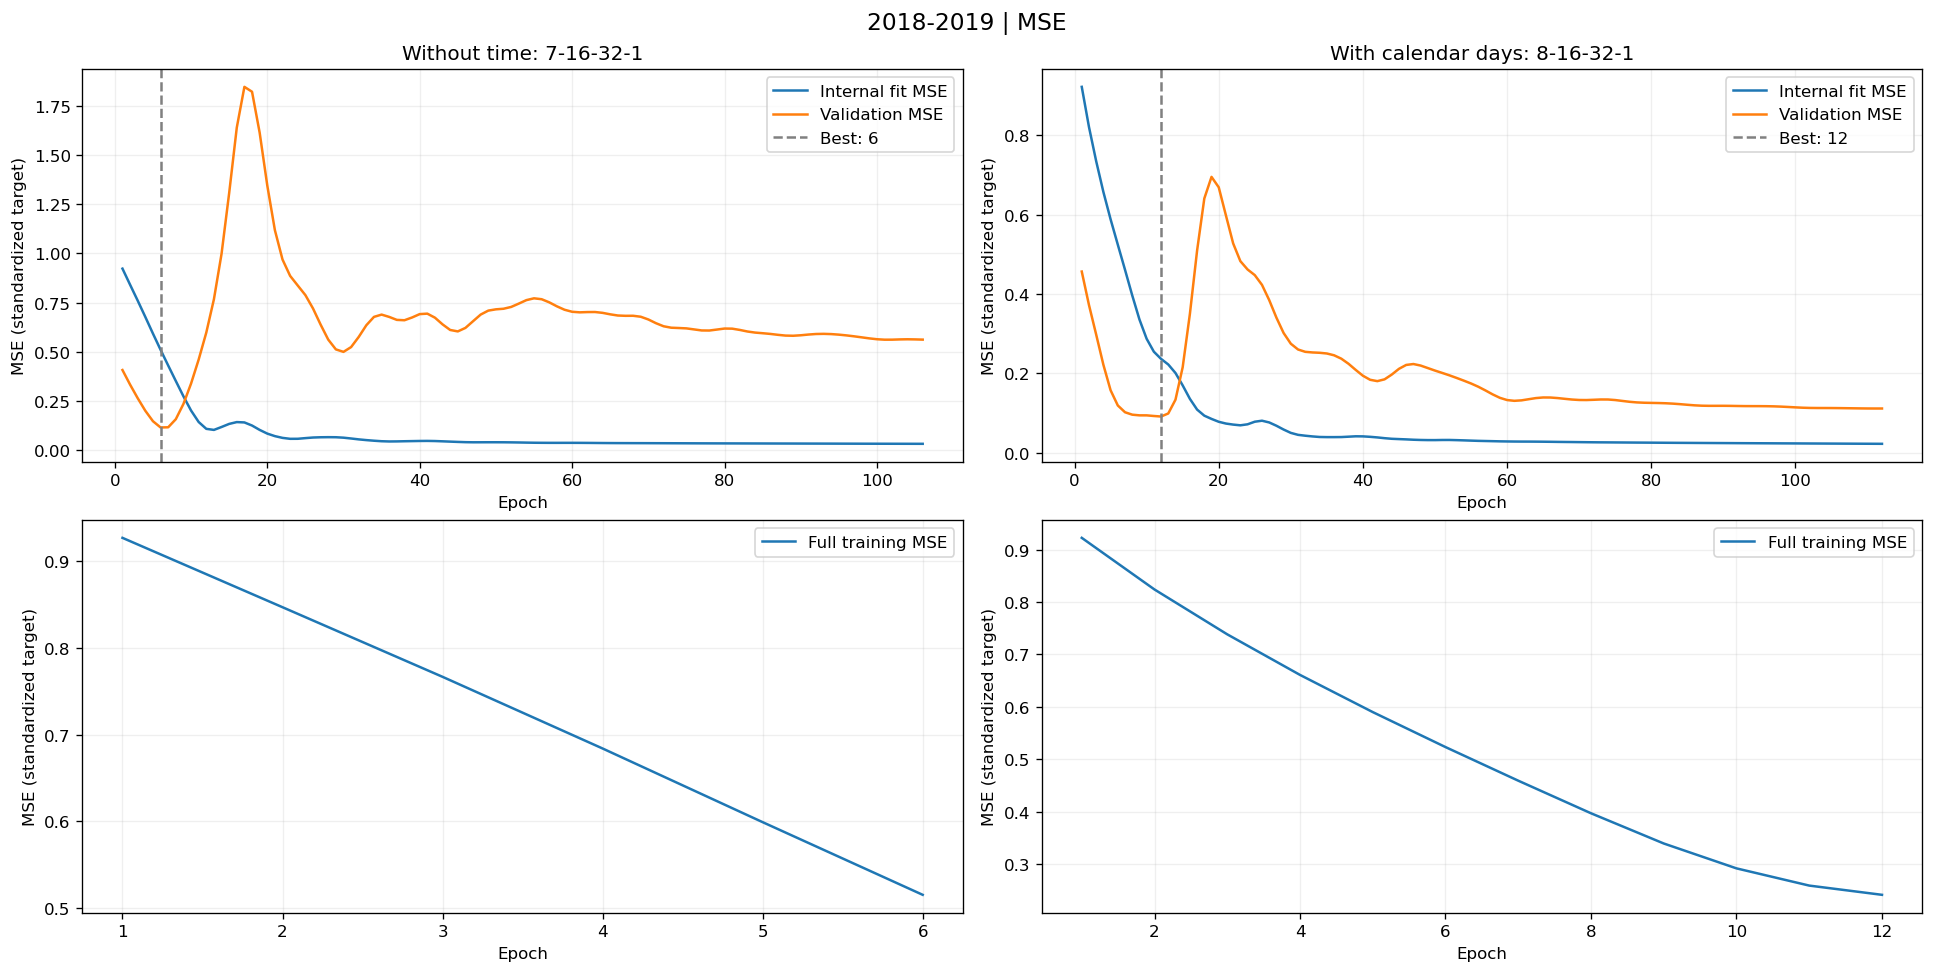

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
for j, (key, label) in enumerate([('base', 'Without time: 7-16-32-1'), ('time', 'With calendar days: 8-16-32-1')]):
    run = runs[key]
    h = run['history']
    axes[0, j].plot(h.epoch, h.fit_mse, label='Internal fit MSE')
    axes[0, j].plot(h.epoch, h.val_mse, label='Validation MSE')
    axes[0, j].axvline(run['best_epoch'], color='gray', linestyle='--', label=f'Best: {run["best_epoch"]}')
    axes[0, j].set_title(label)
    axes[1, j].plot(range(1, len(run['final_curve']) + 1), run['final_curve'], label='Full training MSE')
for ax in axes.flat:
    ax.set(xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle(STAGE + ' | MSE', fontsize=14)
fig.savefig(OUT / 'mse_comparison.png', dpi=140)
plt.show()


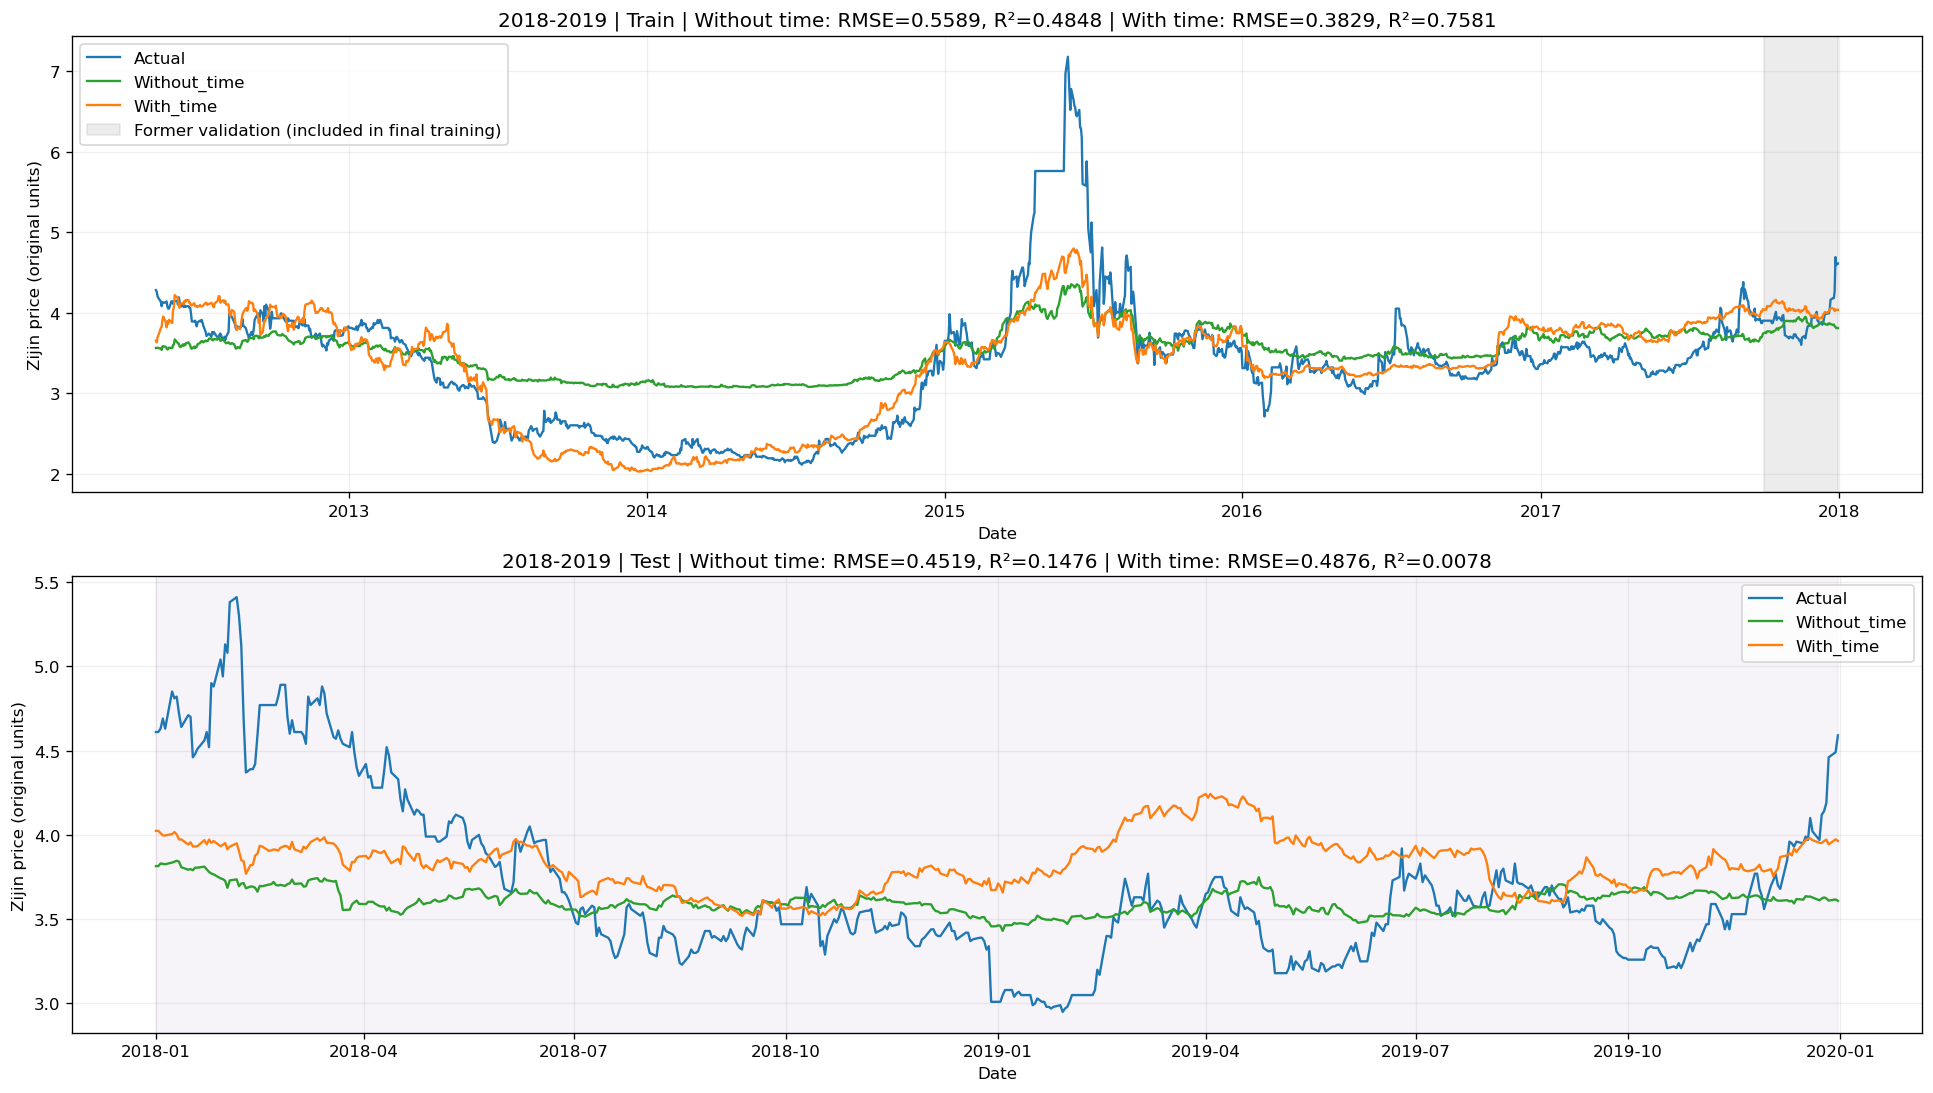

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split, idx in zip(axes, ['Train', 'Test'], [train_index, test_index]):
    frame = pd.DataFrame({'Actual': np.asarray(Y.loc[idx]).ravel(),
        'Without_time': runs['base']['preds'][split], 'With_time': runs['time']['preds'][split]}, index=idx)
    assert np.isfinite(frame.to_numpy()).all()
    frame.to_csv(OUT / f'{split.lower()}_predictions.csv')
    for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
        ax.plot(idx, frame[name], label=name, color=color, linewidth=1.4)
    if split == 'Train':
        ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final training)')
    else:
        ax.axvspan(idx.min(), idx.max(), color='tab:purple', alpha=0.08)
    a, b = metrics.loc[(split + ' (final)', 'base')], metrics.loc[(split + ' (final)', 'time')]
    ax.set(title=f'{STAGE} | {split} | Without time: RMSE={a.RMSE:.4f}, R²={a["R²"]:.4f}'
        f' | With time: RMSE={b.RMSE:.4f}, R²={b["R²"]:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'prediction_comparison.png', dpi=140)
plt.show()


## 测试阶段：2020-2021

内部验证：2019-10-01至2019-12-31；最终训练截至2019年底，测试截至2021年底。

In [ ]:
STAGE = '2020-2021'
TEST_START, TEST_END = pd.Timestamp('2020-01-01'), pd.Timestamp('2022-01-01')
VAL_START = TEST_START - pd.DateOffset(months=3)
OUT = EXPERIMENT_OUT / STAGE
OUT.mkdir(parents=True, exist_ok=True)
train_index = X_base.index[X_base.index < TEST_START]
fit_index = train_index[train_index < VAL_START]
val_index = train_index[train_index >= VAL_START]
test_index = X_base.index[(X_base.index >= TEST_START) & (X_base.index < TEST_END)]
assert len(fit_index) and len(val_index) and len(test_index)
assert fit_index.max() < val_index.min() <= val_index.max() < test_index.min()
split_info = pd.DataFrame([{'Split': name, 'N': len(idx), 'Start': idx.min(), 'End': idx.max()}
    for name, idx in [('Fit', fit_index), ('Validation', val_index), ('Train', train_index), ('Test', test_index)]])
display(split_info)
split_info.to_csv(OUT / 'split_info.csv', index=False)
runs = {'base': train_variant(X_base, 'base'), 'time': train_variant(X_time, 'time')}
selection = pd.DataFrame([{'模型': key, '输入数': 7 if key == 'base' else 8,
    '参数量': sum(p.numel() for p in run['model'].parameters()),
    '最佳轮数': run['best_epoch'], '停止轮数': run['stopped_epoch']}
    for key, run in runs.items()])
display(selection)

metric_rows = []
for key, run in runs.items():
    for split, idx, pred in [('Validation (internal best)', val_index, run['val_pred']),
                             ('Train (final)', train_index, run['preds']['Train']),
                             ('Test (final)', test_index, run['preds']['Test'])]:
        truth = np.asarray(Y.loc[idx]).ravel()
        pred = np.asarray(pred)
        mse = mean_squared_error(truth, pred)
        metric_rows.append({'模型': key, '评价段': split, '样本数': len(idx),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.abs(truth - pred).mean(), 'R²': r2_score(truth, pred)})
metrics = pd.DataFrame(metric_rows).set_index(['评价段', '模型']).sort_index()
display(metrics.round(4))
metrics.to_csv(OUT / 'metrics.csv')

selection.to_csv(OUT / 'selection.csv', index=False)
stage_results[STAGE] = {'metrics': metrics.copy(), 'selection': selection.copy()}


,Split,N,Start,End
0,Fit,1987,2012-05-09,2019-09-30
1,Validation,67,2019-10-01,2019-12-31
2,Train,2054,2012-05-09,2019-12-31
3,Test,543,2020-01-01,2021-12-31


,模型,输入数,参数量,最佳轮数,停止轮数
0,base,7,705,521,621
1,time,8,721,13,113


样本数      MSE    RMSE     MAE      R²
评价段                        模型                                         
Test (final)               base   543   5.7421  2.3963  1.9914  0.3275
                           time   543  17.1631  4.1428  3.5303 -1.0101
Train (final)              base  2054   0.0090  0.0950  0.0686  0.9829
                           time  2054   0.1262  0.3553  0.2592  0.7613
Validation (internal best) base    67   0.0467  0.2161  0.1812  0.5959
                           time    67   0.0668  0.2584  0.2122  0.4224

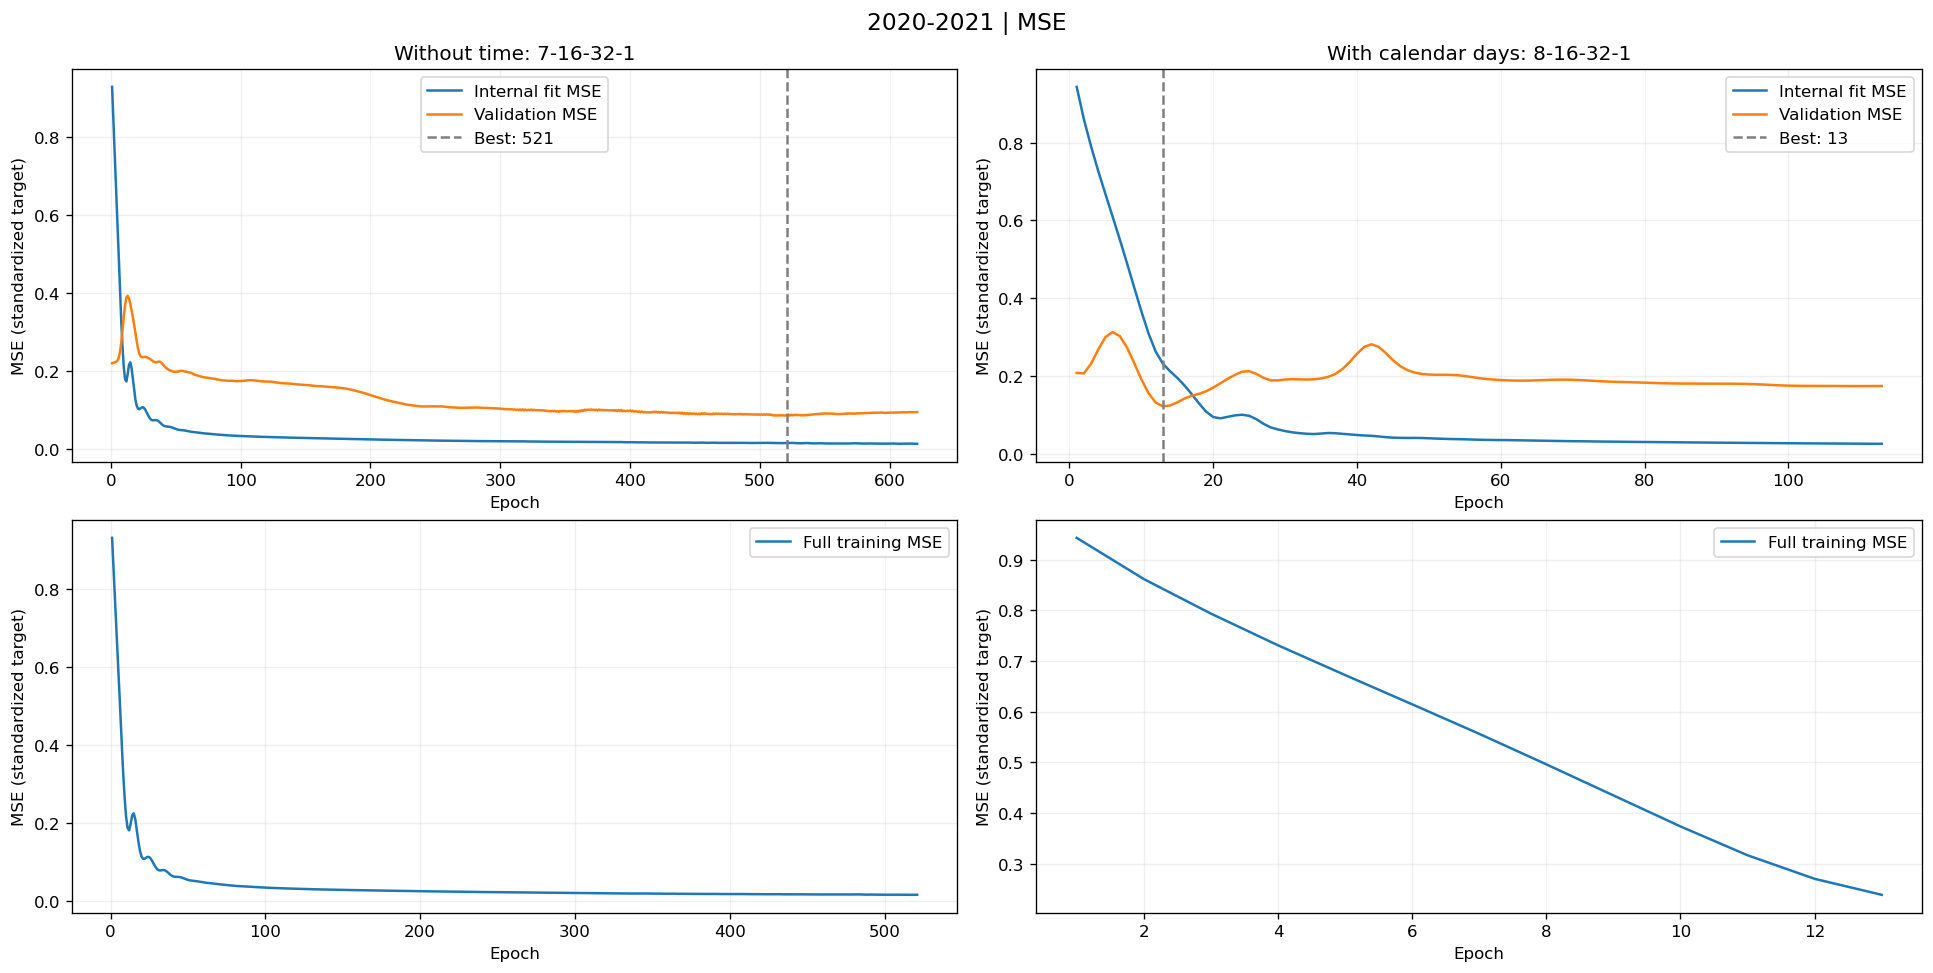

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
for j, (key, label) in enumerate([('base', 'Without time: 7-16-32-1'), ('time', 'With calendar days: 8-16-32-1')]):
    run = runs[key]
    h = run['history']
    axes[0, j].plot(h.epoch, h.fit_mse, label='Internal fit MSE')
    axes[0, j].plot(h.epoch, h.val_mse, label='Validation MSE')
    axes[0, j].axvline(run['best_epoch'], color='gray', linestyle='--', label=f'Best: {run["best_epoch"]}')
    axes[0, j].set_title(label)
    axes[1, j].plot(range(1, len(run['final_curve']) + 1), run['final_curve'], label='Full training MSE')
for ax in axes.flat:
    ax.set(xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle(STAGE + ' | MSE', fontsize=14)
fig.savefig(OUT / 'mse_comparison.png', dpi=140)
plt.show()


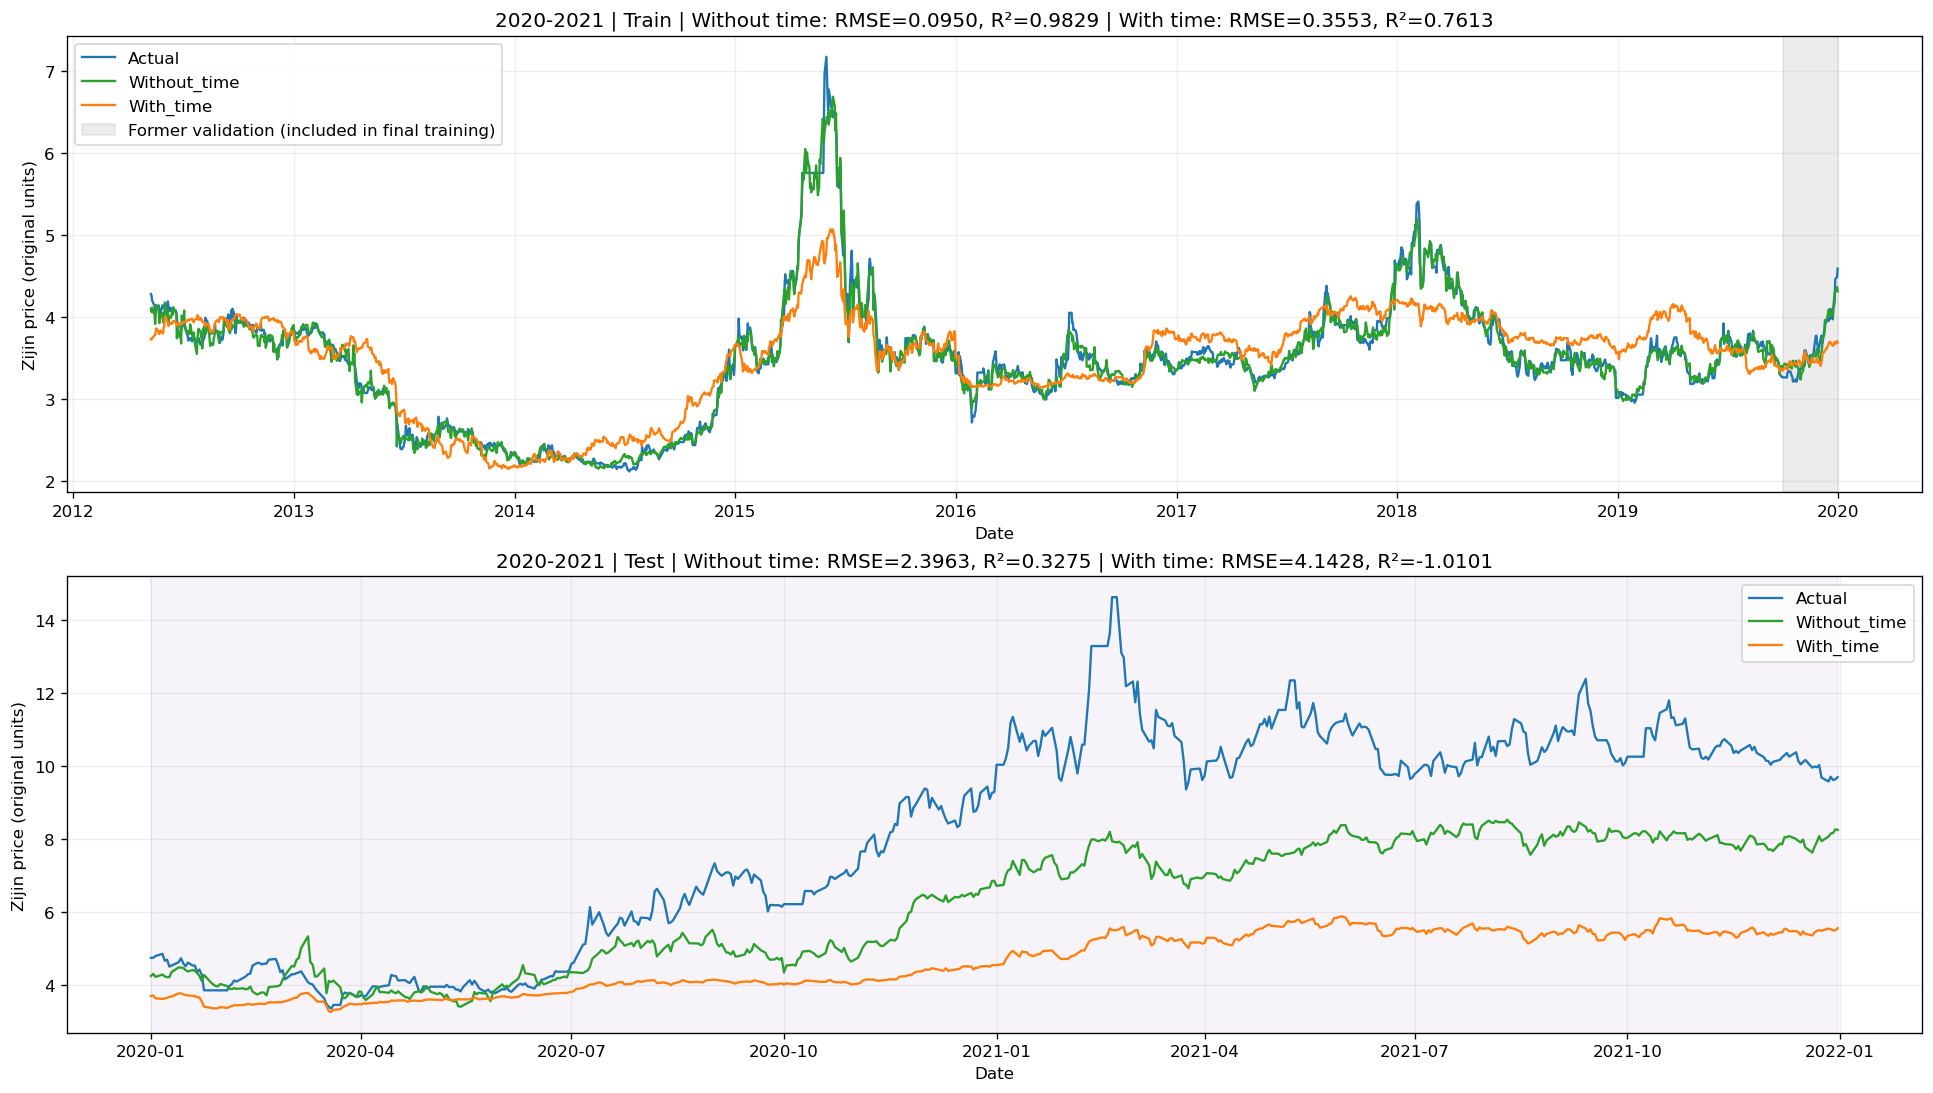

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split, idx in zip(axes, ['Train', 'Test'], [train_index, test_index]):
    frame = pd.DataFrame({'Actual': np.asarray(Y.loc[idx]).ravel(),
        'Without_time': runs['base']['preds'][split], 'With_time': runs['time']['preds'][split]}, index=idx)
    assert np.isfinite(frame.to_numpy()).all()
    frame.to_csv(OUT / f'{split.lower()}_predictions.csv')
    for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
        ax.plot(idx, frame[name], label=name, color=color, linewidth=1.4)
    if split == 'Train':
        ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final training)')
    else:
        ax.axvspan(idx.min(), idx.max(), color='tab:purple', alpha=0.08)
    a, b = metrics.loc[(split + ' (final)', 'base')], metrics.loc[(split + ' (final)', 'time')]
    ax.set(title=f'{STAGE} | {split} | Without time: RMSE={a.RMSE:.4f}, R²={a["R²"]:.4f}'
        f' | With time: RMSE={b.RMSE:.4f}, R²={b["R²"]:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'prediction_comparison.png', dpi=140)
plt.show()


## 测试阶段：2022-2023

内部验证：2021-10-01至2021-12-31；最终训练截至2021年底，测试截至2023年底。

In [ ]:
STAGE = '2022-2023'
TEST_START, TEST_END = pd.Timestamp('2022-01-01'), pd.Timestamp('2024-01-01')
VAL_START = TEST_START - pd.DateOffset(months=3)
OUT = EXPERIMENT_OUT / STAGE
OUT.mkdir(parents=True, exist_ok=True)
train_index = X_base.index[X_base.index < TEST_START]
fit_index = train_index[train_index < VAL_START]
val_index = train_index[train_index >= VAL_START]
test_index = X_base.index[(X_base.index >= TEST_START) & (X_base.index < TEST_END)]
assert len(fit_index) and len(val_index) and len(test_index)
assert fit_index.max() < val_index.min() <= val_index.max() < test_index.min()
split_info = pd.DataFrame([{'Split': name, 'N': len(idx), 'Start': idx.min(), 'End': idx.max()}
    for name, idx in [('Fit', fit_index), ('Validation', val_index), ('Train', train_index), ('Test', test_index)]])
display(split_info)
split_info.to_csv(OUT / 'split_info.csv', index=False)
runs = {'base': train_variant(X_base, 'base'), 'time': train_variant(X_time, 'time')}
selection = pd.DataFrame([{'模型': key, '输入数': 7 if key == 'base' else 8,
    '参数量': sum(p.numel() for p in run['model'].parameters()),
    '最佳轮数': run['best_epoch'], '停止轮数': run['stopped_epoch']}
    for key, run in runs.items()])
display(selection)

metric_rows = []
for key, run in runs.items():
    for split, idx, pred in [('Validation (internal best)', val_index, run['val_pred']),
                             ('Train (final)', train_index, run['preds']['Train']),
                             ('Test (final)', test_index, run['preds']['Test'])]:
        truth = np.asarray(Y.loc[idx]).ravel()
        pred = np.asarray(pred)
        mse = mean_squared_error(truth, pred)
        metric_rows.append({'模型': key, '评价段': split, '样本数': len(idx),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.abs(truth - pred).mean(), 'R²': r2_score(truth, pred)})
metrics = pd.DataFrame(metric_rows).set_index(['评价段', '模型']).sort_index()
display(metrics.round(4))
metrics.to_csv(OUT / 'metrics.csv')

selection.to_csv(OUT / 'selection.csv', index=False)
stage_results[STAGE] = {'metrics': metrics.copy(), 'selection': selection.copy()}


,Split,N,Start,End
0,Fit,2530,2012-05-09,2021-09-30
1,Validation,67,2021-10-01,2021-12-31
2,Train,2597,2012-05-09,2021-12-31
3,Test,547,2022-01-03,2023-12-31


,模型,输入数,参数量,最佳轮数,停止轮数
0,base,7,705,54,154
1,time,8,721,26,126


样本数      MSE    RMSE     MAE       R²
评价段                        模型                                          
Test (final)               base   547  17.6056  4.1959  3.7027  -7.1337
                           time   547  29.3349  5.4162  5.0352 -12.5526
Train (final)              base  2597   0.1193  0.3454  0.2308   0.9797
                           time  2597   0.2009  0.4482  0.3324   0.9658
Validation (internal best) base    67   0.1393  0.3733  0.2779   0.3908
                           time    67   0.1421  0.3770  0.2686   0.3786

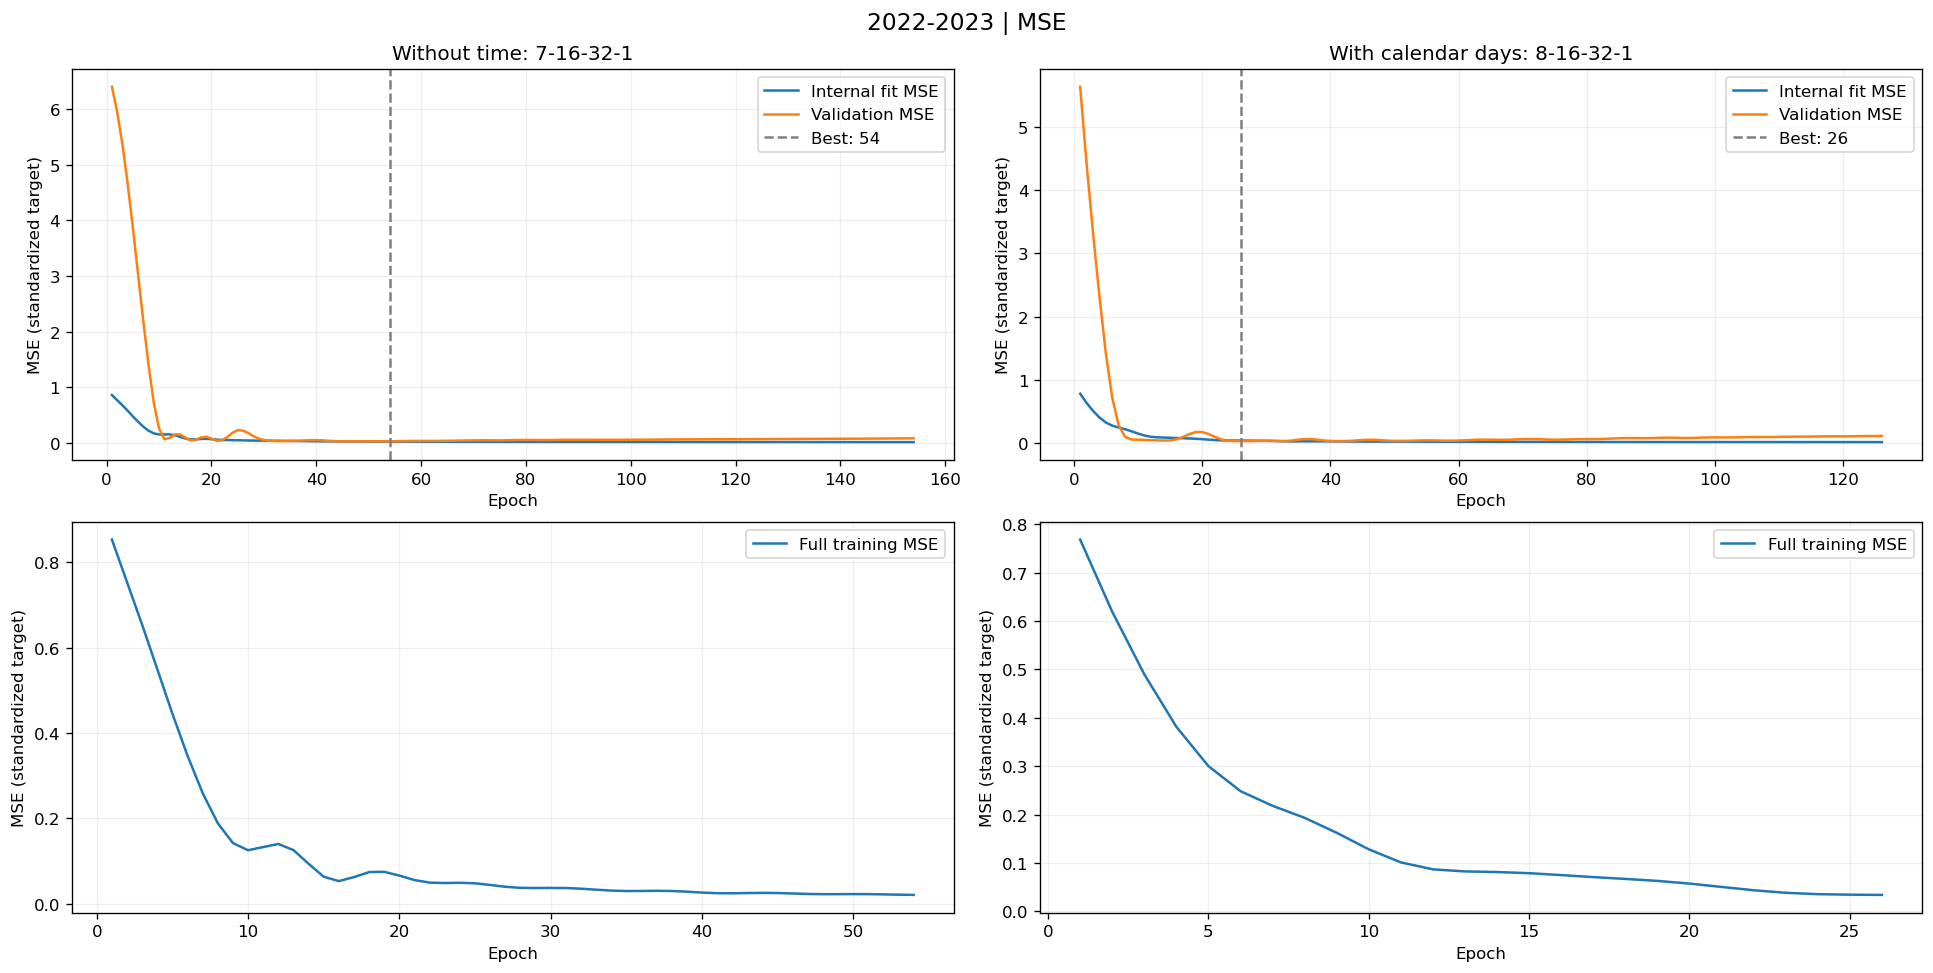

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
for j, (key, label) in enumerate([('base', 'Without time: 7-16-32-1'), ('time', 'With calendar days: 8-16-32-1')]):
    run = runs[key]
    h = run['history']
    axes[0, j].plot(h.epoch, h.fit_mse, label='Internal fit MSE')
    axes[0, j].plot(h.epoch, h.val_mse, label='Validation MSE')
    axes[0, j].axvline(run['best_epoch'], color='gray', linestyle='--', label=f'Best: {run["best_epoch"]}')
    axes[0, j].set_title(label)
    axes[1, j].plot(range(1, len(run['final_curve']) + 1), run['final_curve'], label='Full training MSE')
for ax in axes.flat:
    ax.set(xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle(STAGE + ' | MSE', fontsize=14)
fig.savefig(OUT / 'mse_comparison.png', dpi=140)
plt.show()


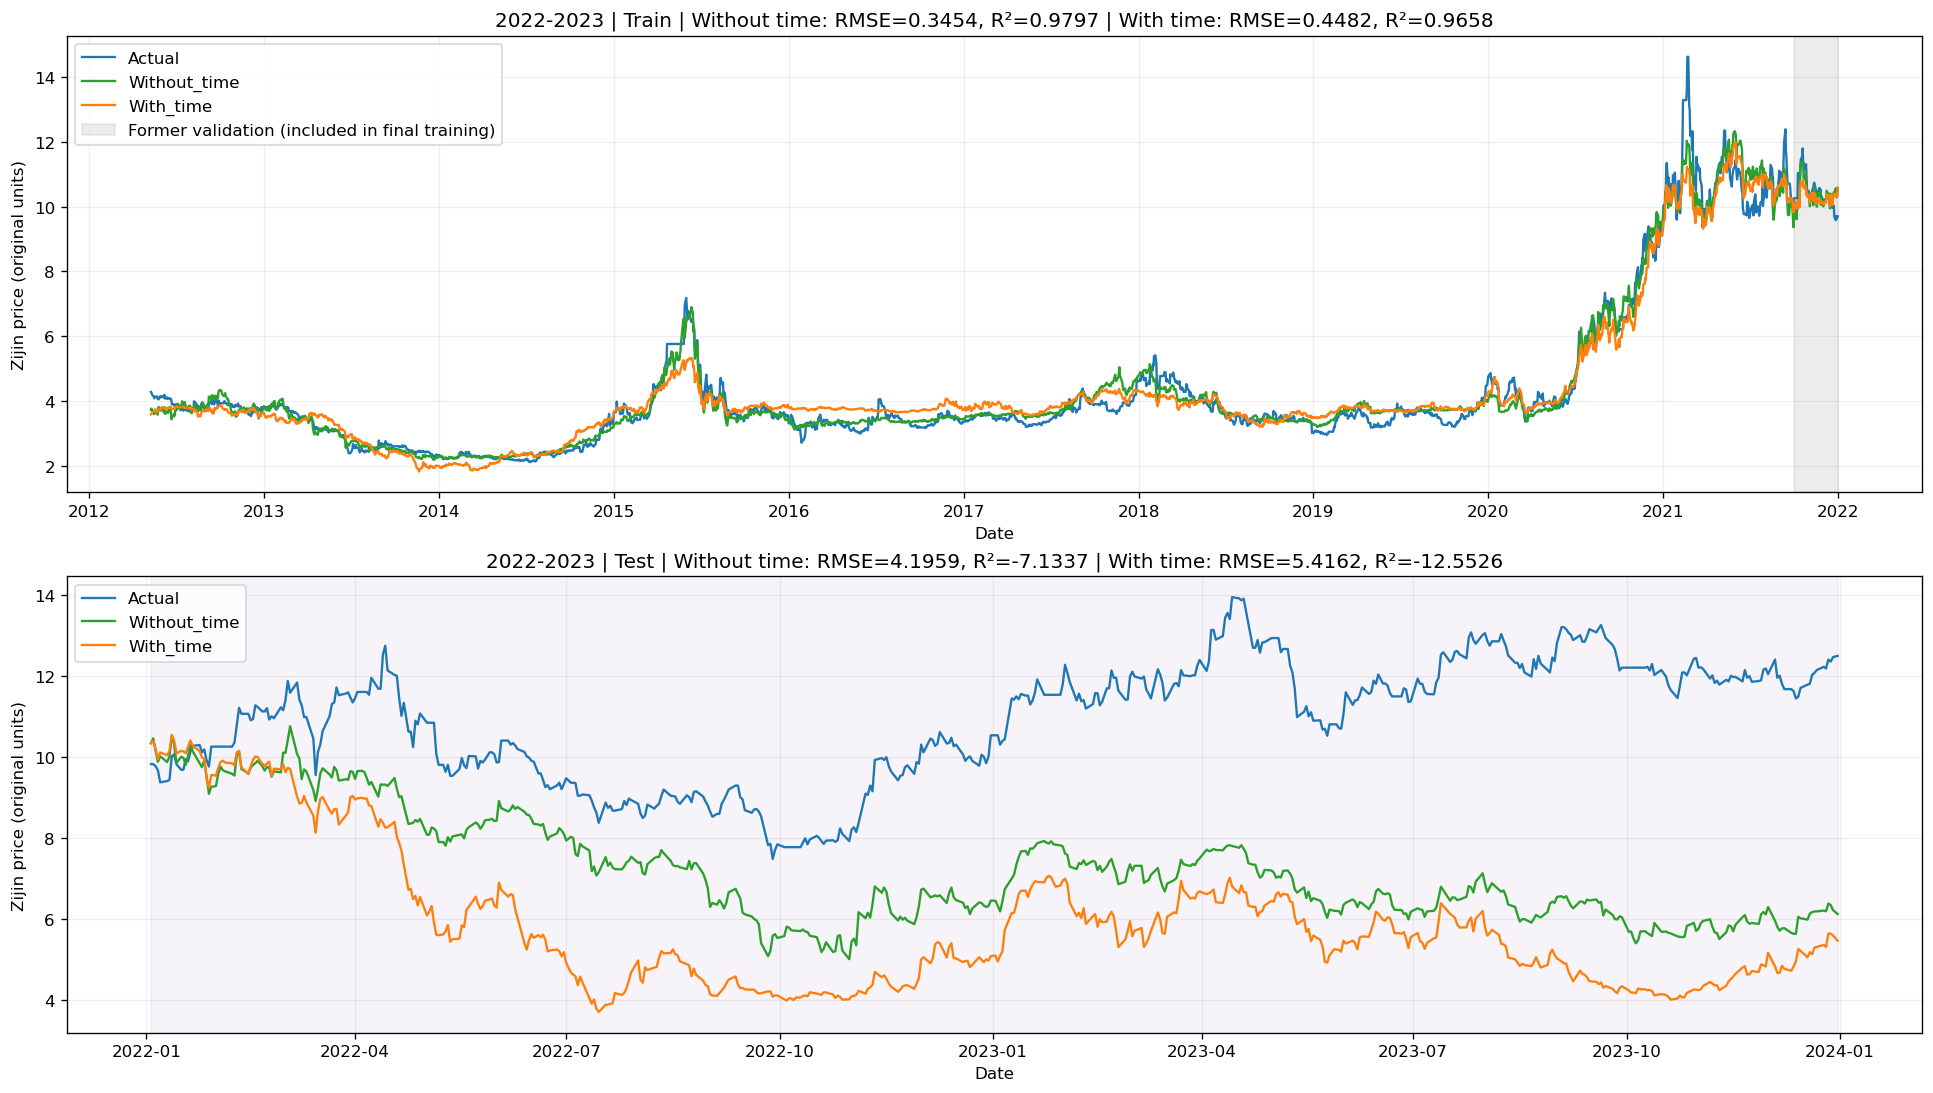

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split, idx in zip(axes, ['Train', 'Test'], [train_index, test_index]):
    frame = pd.DataFrame({'Actual': np.asarray(Y.loc[idx]).ravel(),
        'Without_time': runs['base']['preds'][split], 'With_time': runs['time']['preds'][split]}, index=idx)
    assert np.isfinite(frame.to_numpy()).all()
    frame.to_csv(OUT / f'{split.lower()}_predictions.csv')
    for name, color in [('Actual', 'tab:blue'), ('Without_time', 'tab:green'), ('With_time', 'tab:orange')]:
        ax.plot(idx, frame[name], label=name, color=color, linewidth=1.4)
    if split == 'Train':
        ax.axvspan(val_index.min(), val_index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final training)')
    else:
        ax.axvspan(idx.min(), idx.max(), color='tab:purple', alpha=0.08)
    a, b = metrics.loc[(split + ' (final)', 'base')], metrics.loc[(split + ' (final)', 'time')]
    ax.set(title=f'{STAGE} | {split} | Without time: RMSE={a.RMSE:.4f}, R²={a["R²"]:.4f}'
        f' | With time: RMSE={b.RMSE:.4f}, R²={b["R²"]:.4f}', xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'prediction_comparison.png', dpi=140)
plt.show()


## 四个阶段的测试指标与等权平均

平均RMSE越低越好，平均R²越高越好；同时报告逐阶段胜负，防止平均值掩盖不稳定性。验证分数使用内部模型，图中灰色区域则已经参与最终模型重训。

四阶段等权算术平均：
加入时间：RMSE改善 0/4 个阶段，R²改善 0/4 个阶段。
平均RMSE变化（有时间减无时间）： 0.7599
平均R²变化（有时间减无时间）： -1.7894
当前结果不足以支持时间特征稳定有效，应保留全部阶段结果而非只选改善的时期。


RMSE                     R2             
Model     With_time Without_time With_time Without_time
Stage                                                  
2016-2017    0.3195       0.2825   -0.1968       0.0646
2018-2019    0.4876       0.4519    0.0078       0.1476
2020-2021    4.1428       2.3963   -1.0101       0.3275
2022-2023    5.4162       4.1959  -12.5526      -7.1337

,RMSE,R2
Model,,
With_time,2.5915,-3.4379
Without_time,1.8316,-1.6485


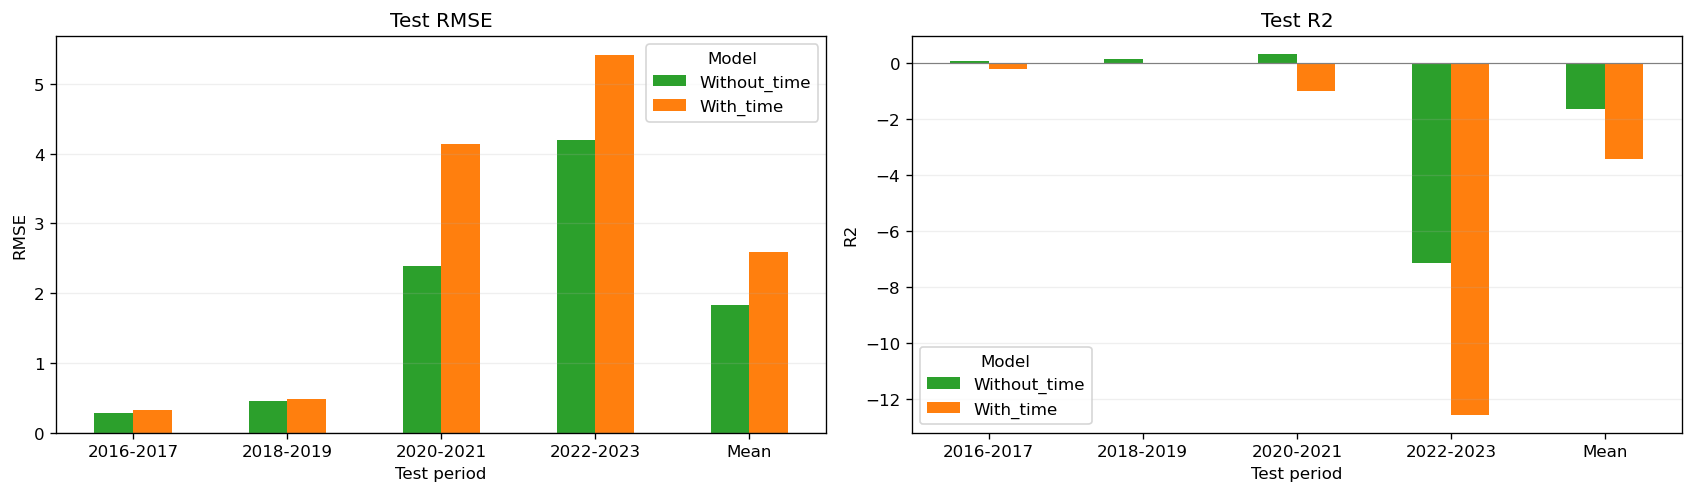

In [ ]:
assert set(stage_results) == {'2016-2017', '2018-2019', '2020-2021', '2022-2023'}
rows = []
for stage, result in stage_results.items():
    for key, label in [('base', 'Without_time'), ('time', 'With_time')]:
        score = result['metrics'].loc[('Test (final)', key)]
        rows.append({'Stage': stage, 'Model': label, 'N': int(score['样本数']),
            'RMSE': score.RMSE, 'R2': score['R²']})
stage_scores = pd.DataFrame(rows)
comparison = stage_scores.pivot(index='Stage', columns='Model', values=['RMSE', 'R2'])
mean_scores = stage_scores.groupby('Model')[['RMSE', 'R2']].mean()
display(comparison.round(4))
print('四阶段等权算术平均：')
display(mean_scores.round(4))
stage_scores.to_csv(EXPERIMENT_OUT / 'stage_test_metrics.csv', index=False)
mean_scores.to_csv(EXPERIMENT_OUT / 'mean_test_metrics.csv')
rmse_wins = int((comparison['RMSE']['With_time'] < comparison['RMSE']['Without_time']).sum())
r2_wins = int((comparison['R2']['With_time'] > comparison['R2']['Without_time']).sum())
print(f'加入时间：RMSE改善 {rmse_wins}/4 个阶段，R²改善 {r2_wins}/4 个阶段。')
print('平均RMSE变化（有时间减无时间）：', round(mean_scores.loc['With_time', 'RMSE']-mean_scores.loc['Without_time', 'RMSE'], 4))
print('平均R²变化（有时间减无时间）：', round(mean_scores.loc['With_time', 'R2']-mean_scores.loc['Without_time', 'R2'], 4))
if rmse_wins == 4:
    print('这四段固定种子实验一致支持保留时间特征；仍不能推出所有未来时期都有效。')
elif mean_scores.loc['With_time', 'RMSE'] < mean_scores.loc['Without_time', 'RMSE'] and mean_scores.loc['With_time', 'R2'] > mean_scores.loc['Without_time', 'R2']:
    print('平均指标支持时间特征，但效果因时期而异，不能称为普遍有效的证明。')
else:
    print('当前结果不足以支持时间特征稳定有效，应保留全部阶段结果而非只选改善的时期。')
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
for ax, metric in zip(axes, ['RMSE', 'R2']):
    data = comparison[metric].copy()
    data.loc['Mean'] = mean_scores[metric]
    data[['Without_time', 'With_time']].plot.bar(ax=ax, color=['tab:green', 'tab:orange'], rot=0)
    ax.set(title='Test ' + metric, ylabel=metric, xlabel='Test period')
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.grid(axis='y', alpha=0.2)
fig.savefig(EXPERIMENT_OUT / 'test_metrics_summary.png', dpi=140)
plt.show()


本节使用固定种子的一次分期比较，两个输入维度下的初始化并非逐项相同；各自选轮也可能不同。日历天数作为普通MLP的输入，不等同于序列模型。本次保留原始同日因子解释同日股价的目标口径。

### 本次结果解释

四个测试阶段加入时间后RMSE均升高、R²均降低。等权平均RMSE：无时间 **1.8316**，有时间 **2.5915**；平均R²：无时间 **−1.6485**，有时间 **−3.4379**。因此当前实验不支持“时间特征稳定有效”的结论。

应结合选轮结果理解：2016—2017两组均只选择2轮；2018—2019选择6／12轮；2020—2021选择521／13轮；2022—2023选择54／26轮（依次无时间／有时间）。这是验证误差选轮，并非训练已经收敛，最终重训轮数也跟随该选择。因此本次比较的是“加入时间并按同一规则独立选轮”的完整流程，不是固定相同训练轮数下时间输入的单独效应。

两年测试跨度也长于上一轮的2026年4—7月。未来日期对应未见过的时间数值，模型需要外推；这可以构成效果不稳定的一种解释，但本实验尚未分离其与初始化、选轮等因素的影响。

全部图像、逐阶段指标、均值、预测明细与8个模型参数保存在 `results/mlp_time_dimension_05_four_periods/`。

在早起模型训练中,大概率存在模型训练不充分的问题,最早的数据存在2轮训练取得最小值.此外验证集有点偏大,没有仔细查看这段时间范围内变量范围的变化.结论先存疑.